# Quantum Machine Learning – Unified Encoding Benchmark (v11 — 600 Samples, Corrected & Expanded)
**BTP Project | ~600 samples/dataset · Full Qubit Sweep (2–8) · 17 Encodings · Multiclass**

### Changes from v9

| Change | Detail |
|---|---|
| N_SAMPLES → 600 | 120 per class → ≈450 train + 150 test |
| VQC depth → 6 | `StronglyEntanglingLayers` with `n_layers=6` (was 2) |
| Multiclass | 5-class MNIST (0–4), 5-class FMNIST (0–4), 10-class Digits; SVM via OneVsRestClassifier |
| **Corrected IQP** | Now TWO full H→RZ(xⱼ)→RZZ(xⱼxₖ) all-pairs layers (was nearest-neighbour IsingZZ only) |
| **Corrected QHE** | Now H→PhaseShift(2πx/λ)→adjoint(QFT) as per QHE paper; old version was just RY+RZ+CRZ |
| **Corrected DenseAngle** | Now H→RZ(xᵢ²)→CNOT+RZ(xᵢxⱼ)+CNOT cross-terms (BTP reference); old was just RY+RZ |
| **Corrected FRQI** | Now H→CRY(2θ, [i,(i+1)%n]) circular structure (FRQI/NEQR paper); old had wrong ctrl wires |
| +NEQR | H→RZ(2πx/π)→PhaseShift+CNOT→CNOT ladder (FRQI/NEQR paper, fixed version) |
| +Hamiltonian | Trotterised exp(-itH(x)), H=ΣxᵢZᵢ+ΣxᵢxⱼXᵢXⱼ (arXiv:2504.10542) |
| +SimpleAngle | RX(xⱼ) per qubit (Zang et al., arXiv:2505.14295) |
| +Pi4Angle | H→RY(2xⱼ) per qubit (Zang et al.) |
| +EntangledAngle | H→RY(xⱼ)→CNOT chain (Zang et al.) |
| +ShotBased | Probability-weighted RY + CRY entanglement (BTP benchmark) |
| +GraphEncoding | Graph Laplacian eigenvalue/eigenvector encoding + CZ (BTP benchmark) |
| +AQHE_LogHelix | H→LogPhaseShift→IQFT (log-compressed phase, QHE v6 paper) |
| +AQHE_FibSpiral | RY(arccos-polar)→PhaseShift(golden-angle)→IQFT (QHE v6 paper) |
| +AQHE_DualEnc | RY(arctan-amp)→PhaseShift(log-phase)→IQFT (QHE v6 paper) |


## 0a · Package Setup

In [4]:
import subprocess, sys

REQUIRED = ["pennylane", "pennylane-lightning", "scikit-learn", "matplotlib", "joblib", "pandas"]
OPTIONAL = ["tensorflow"]

def _pip_install(pkg):
    try:
        __import__(pkg.replace("-", "_").split("==")[0])
        print(f"  [OK] {pkg} already installed")
        return True
    except ImportError:
        print(f"  [..] installing {pkg} ...")
        result = subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                                capture_output=True, text=True)
        if result.returncode == 0:
            print(f"  [OK] {pkg} installed")
            return True
        else:
            print(f"  [FAIL] {pkg}: {result.stderr.strip()[:200]}")
            return False

print("Required packages:")
for p in REQUIRED:
    _pip_install(p)
print("\nOptional (real MNIST/FashionMNIST; falls back to sklearn digits otherwise):")
for p in OPTIONAL:
    ok = _pip_install(p)
    if not ok:
        print(f"     -> without {p}, datasets will use sklearn-digits proxies")


Required packages:
  [OK] pennylane already installed
  [OK] pennylane-lightning already installed
  [..] installing scikit-learn ...
  [OK] scikit-learn installed
  [OK] matplotlib already installed
  [OK] joblib already installed
  [OK] pandas already installed

Optional (real MNIST/FashionMNIST; falls back to sklearn digits otherwise):
  [OK] tensorflow already installed


## 0b · Imports & Global Config

In [5]:
import warnings, time, itertools, os, math
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pennylane as qml
from joblib import Parallel, delayed

SEED = 42
rng  = np.random.default_rng(SEED)
np.random.seed(SEED)

OUTPUT_DIR = Path.cwd() / "qml_outputs_v10"
OUTPUT_DIR.mkdir(exist_ok=True)
print("Figures will be saved to:", OUTPUT_DIR.resolve())

def get_device(n_qubits):
    try:
        return qml.device("lightning.qubit", wires=n_qubits)
    except Exception:
        return qml.device("default.qubit", wires=n_qubits)

print("Simulator backend:", get_device(2).name)
N_CORES = os.cpu_count() or 1
print(f"CPU cores detected: {N_CORES}")

# ── QUICK_TEST toggle ──────────────────────────────────────────────────────────
QUICK_TEST = False   # Set to False for the full 600-sample run

if QUICK_TEST:
    N_SAMPLES   = 20         # per class
    N_QUBITS    = 4
    N_EPOCHS    = 6
    N_CLASSES   = 3
    PCA_DIMS    = [2, 4]
    QUBIT_SWEEP = [2, 3, 4]
    print("\n*** QUICK_TEST = True -> fast sanity run. Set False for full run. ***")
else:
    N_SAMPLES   = 120        # per class -> ~600 total/dataset
    N_QUBITS    = 6
    N_EPOCHS    = 30
    N_CLASSES   = 5
    PCA_DIMS    = [2, 4, 6, 8]
    QUBIT_SWEEP = [2, 3, 4, 5, 6, 7, 8]
    print("\n*** QUICK_TEST = False -> FULL run (N_SAMPLES=120/class, ~600 total). ***")

N_JOBS       = -1
BATCH_SIZE   = 32   # Mini-batch size for VQC training (prevents full-dataset gradient)
STEP_SIZE    = 0.01  # Adam lr (was 0.05 for vanilla GD; Adam is more robust)
DEFAULT_PCA  = 4
VQC_LAYERS   = 2   # Reduced from 6 to 2 to avoid barren plateaus (gradient vanishing)

# Constants for AQHE encodings (QHE v6 paper)
GOLDEN_ANGLE = 2 * np.pi * (1.0 - 1.0 / ((1.0 + np.sqrt(5)) / 2.0))  # golden angle ≈ 2.3999 rad
LOG_BETA     = 3.0
LAMBDA_QHE   = 2 * np.pi

DATASETS  = ["MNIST_5cls", "FMNIST_5cls", "Digits_10cls"]
ENCODINGS = [
    "Rotational", "SimpleAngle", "Pi4Angle", "EntangledAngle",
    "Basis", "Amplitude", "DenseAngle", "ShotBased",
    "FRQI", "NEQR", "IQP", "QHE",
    "Hamiltonian", "GraphEncoding",
    "AQHE_LogHelix", "AQHE_FibSpiral", "AQHE_DualEnc",
]

print("\nConfig:")
print(f"  N_QUBITS={N_QUBITS}, N_SAMPLES/class={N_SAMPLES}, N_EPOCHS={N_EPOCHS}, VQC_LAYERS={VQC_LAYERS}")
print(f"  N_CLASSES={N_CLASSES} (MNIST/FMNIST), 10 (Digits)")
print(f"  Total encodings: {len(ENCODINGS)}")
print(f"  Encodings: {ENCODINGS}")


Figures will be saved to: C:\Users\MANTAVYA\Downloads\qml_outputs_v10
Simulator backend: lightning.qubit
CPU cores detected: 16

*** QUICK_TEST = False -> FULL run (N_SAMPLES=120/class, ~600 total). ***

Config:
  N_QUBITS=6, N_SAMPLES/class=120, N_EPOCHS=30, VQC_LAYERS=2
  N_CLASSES=5 (MNIST/FMNIST), 10 (Digits)
  Total encodings: 17
  Encodings: ['Rotational', 'SimpleAngle', 'Pi4Angle', 'EntangledAngle', 'Basis', 'Amplitude', 'DenseAngle', 'ShotBased', 'FRQI', 'NEQR', 'IQP', 'QHE', 'Hamiltonian', 'GraphEncoding', 'AQHE_LogHelix', 'AQHE_FibSpiral', 'AQHE_DualEnc']


## 1 · Data Loading & Preprocessing (Multiclass)

**Pipeline:** `Raw images → Flatten → StandardScaler → PCA(k) → MinMax [0,π]`

Datasets:
- **MNIST_5cls**: MNIST digits 0–4 (5 classes)
- **FMNIST_5cls**: FashionMNIST classes 0–4 (5 classes)
- **Digits_10cls**: sklearn Digits, all 10 classes (0–9)

Multiclass SVM uses `OneVsRestClassifier(SVC(kernel='precomputed', C=1.0))`.


In [6]:
def _preprocess(X, pca_dim):
    X = StandardScaler().fit_transform(X)
    X = PCA(n_components=pca_dim, random_state=SEED).fit_transform(X)
    X = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X)
    return X


def _subsample_balanced(X, y, classes, n_per_class):
    idx_parts = []
    for c in classes:
        ci = np.where(y == c)[0]
        np.random.shuffle(ci)
        idx_parts.append(ci[:n_per_class])
    idx = np.concatenate(idx_parts)
    perm = np.random.RandomState(SEED).permutation(len(idx))
    return X[idx[perm]], y[idx[perm]]


def _relabel_consecutive(y, classes):
    lmap = {c: i for i, c in enumerate(sorted(set(classes)))}
    return np.array([lmap[yi] for yi in y])


def _digit_proxy_multi(classes, n_per_class, pca_dim, tag):
    print(f"  [{tag}] using sklearn digits as proxy")
    dig = load_digits()
    available = sorted(set(classes) & set(np.unique(dig.target)))
    mask = np.isin(dig.target, available)
    X, y = _subsample_balanced(dig.data[mask], dig.target[mask], available, n_per_class)
    y_mc = _relabel_consecutive(y, available)
    X = _preprocess(X, pca_dim)
    return (*train_test_split(X, y_mc, test_size=0.25, random_state=SEED, stratify=y_mc), "PROXY")


def load_mnist_multiclass(n_classes=N_CLASSES, n_per_class=N_SAMPLES, pca_dim=DEFAULT_PCA):
    classes = list(range(n_classes))
    tag = f"MNIST_{n_classes}cls"
    # Tier 1: tensorflow
    try:
        from tensorflow.keras.datasets import mnist
        (X_tr, y_tr), (X_te, y_te) = mnist.load_data()
        X = np.concatenate([X_tr, X_te]).reshape(-1, 784) / 255.0
        y = np.concatenate([y_tr, y_te])
        X, y = _subsample_balanced(X, y, classes, n_per_class)
        y_mc = _relabel_consecutive(y, classes)
        X = _preprocess(X, pca_dim)
        print(f"  [{tag}] REAL MNIST via tensorflow ({len(y)} samples, {n_classes} classes)")
        return (*train_test_split(X, y_mc, test_size=0.25, random_state=SEED, stratify=y_mc), "REAL")
    except Exception:
        pass
    # Tier 2: fetch_openml
    try:
        from sklearn.datasets import fetch_openml
        d = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
        X, y = d.data / 255.0, d.target.astype(int)
        X, y = _subsample_balanced(X, y, classes, n_per_class)
        y_mc = _relabel_consecutive(y, classes)
        X = _preprocess(X, pca_dim)
        print(f"  [{tag}] REAL MNIST via fetch_openml ({len(y)} samples, {n_classes} classes)")
        return (*train_test_split(X, y_mc, test_size=0.25, random_state=SEED, stratify=y_mc), "REAL")
    except Exception:
        pass
    return _digit_proxy_multi(classes, n_per_class, pca_dim, tag)


def load_fmnist_multiclass(n_classes=N_CLASSES, n_per_class=N_SAMPLES, pca_dim=DEFAULT_PCA):
    classes = list(range(n_classes))
    tag = f"FMNIST_{n_classes}cls"
    try:
        from tensorflow.keras.datasets import fashion_mnist
        (X_tr, y_tr), (X_te, y_te) = fashion_mnist.load_data()
        X = np.concatenate([X_tr, X_te]).reshape(-1, 784) / 255.0
        y = np.concatenate([y_tr, y_te])
        X, y = _subsample_balanced(X, y, classes, n_per_class)
        y_mc = _relabel_consecutive(y, classes)
        X = _preprocess(X, pca_dim)
        print(f"  [{tag}] REAL FashionMNIST via tensorflow ({len(y)} samples, {n_classes} classes)")
        return (*train_test_split(X, y_mc, test_size=0.25, random_state=SEED, stratify=y_mc), "REAL")
    except Exception:
        pass
    try:
        from sklearn.datasets import fetch_openml
        d = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")
        X, y = d.data / 255.0, d.target.astype(int)
        X, y = _subsample_balanced(X, y, classes, n_per_class)
        y_mc = _relabel_consecutive(y, classes)
        X = _preprocess(X, pca_dim)
        print(f"  [{tag}] REAL FashionMNIST via fetch_openml ({len(y)} samples, {n_classes} classes)")
        return (*train_test_split(X, y_mc, test_size=0.25, random_state=SEED, stratify=y_mc), "REAL")
    except Exception:
        pass
    return _digit_proxy_multi(classes, n_per_class, pca_dim, tag)


def load_digits_multiclass(n_per_class=N_SAMPLES, pca_dim=DEFAULT_PCA):
    dig    = load_digits()
    classes = list(range(10))
    X, y   = _subsample_balanced(dig.data, dig.target, classes, n_per_class)
    y_mc   = _relabel_consecutive(y, classes)
    X      = _preprocess(X, pca_dim)
    n_actual = len(np.unique(y_mc))
    print(f"  [Digits_10cls] sklearn digits all {n_actual} classes ({len(y)} samples)")
    return (*train_test_split(X, y_mc, test_size=0.25, random_state=SEED, stratify=y_mc), "REAL")


print("Loading datasets (N_SAMPLES =", N_SAMPLES, "per class, N_CLASSES =", N_CLASSES, ") ...")
t0 = time.time()
data, data_source = {}, {}

Xtr, Xte, ytr, yte, src = load_mnist_multiclass()
data["MNIST_5cls"]   = (Xtr, Xte, ytr, yte); data_source["MNIST_5cls"]   = src

Xtr, Xte, ytr, yte, src = load_fmnist_multiclass()
data["FMNIST_5cls"]  = (Xtr, Xte, ytr, yte); data_source["FMNIST_5cls"]  = src

Xtr, Xte, ytr, yte, src = load_digits_multiclass()
data["Digits_10cls"] = (Xtr, Xte, ytr, yte); data_source["Digits_10cls"] = src

print(f"\nDone in {time.time()-t0:.1f}s")
for name, (Xtr, Xte, ytr, yte) in data.items():
    n_cls = len(np.unique(np.concatenate([ytr, yte])))
    print(f"  {name:14s} -> train {Xtr.shape}, test {Xte.shape}  "
          f"(total={len(Xtr)+len(Xte)}, {n_cls} classes)  [source: {data_source[name]}]")


Loading datasets (N_SAMPLES = 120 per class, N_CLASSES = 5 ) ...
  [MNIST_5cls] REAL MNIST via tensorflow (600 samples, 5 classes)
  [FMNIST_5cls] REAL FashionMNIST via tensorflow (600 samples, 5 classes)
  [Digits_10cls] sklearn digits all 10 classes (1200 samples)

Done in 2.1s
  MNIST_5cls     -> train (450, 4), test (150, 4)  (total=600, 5 classes)  [source: REAL]
  FMNIST_5cls    -> train (450, 4), test (150, 4)  (total=600, 5 classes)  [source: REAL]
  Digits_10cls   -> train (900, 4), test (300, 4)  (total=1200, 10 classes)  [source: REAL]


## 2 · Full Pipeline Diagram

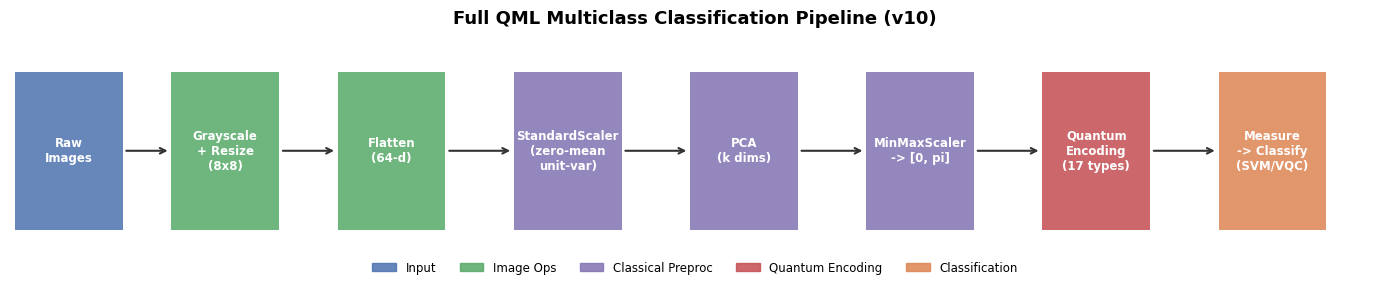

Saved: c:\Users\MANTAVYA\Downloads\qml_outputs_v10\pipeline_diagram.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.set_xlim(0, 14); ax.set_ylim(0, 3); ax.axis("off")
stages = [
    ("Raw\nImages", 0.6), ("Grayscale\n+ Resize\n(8x8)", 2.2), ("Flatten\n(64-d)", 3.9),
    ("StandardScaler\n(zero-mean\nunit-var)", 5.7), ("PCA\n(k dims)", 7.5),
    ("MinMaxScaler\n-> [0, pi]", 9.3), ("Quantum\nEncoding\n(17 types)", 11.1),
    ("Measure\n-> Classify\n(SVM/VQC)", 12.9),
]
colors = ["#4C72B0","#55A868","#55A868","#8172B2","#8172B2","#8172B2","#C44E52","#DD8452"]
for i, (label, x) in enumerate(stages):
    ax.add_patch(plt.Rectangle((x-0.55, 0.5), 1.1, 2.0, color=colors[i], alpha=0.85, zorder=2, linewidth=0))
    ax.text(x, 1.5, label, ha="center", va="center", fontsize=8.5, color="white", fontweight="bold", zorder=3)
    if i < len(stages)-1:
        ax.annotate("", xy=(stages[i+1][1]-0.56, 1.5), xytext=(x+0.56, 1.5),
                    arrowprops=dict(arrowstyle="->", color="#333", lw=1.5))
legend_items = [plt.Rectangle((0,0),1,1, color=c, alpha=0.85)
                for c in ["#4C72B0","#55A868","#8172B2","#C44E52","#DD8452"]]
ax.legend(legend_items, ["Input","Image Ops","Classical Preproc","Quantum Encoding","Classification"],
          loc="upper center", bbox_to_anchor=(0.5, 0.08), ncol=5, fontsize=8.5, frameon=False)
ax.set_title("Full QML Multiclass Classification Pipeline (v10)", fontsize=13, fontweight="bold", pad=6)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pipeline_diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", OUTPUT_DIR / "pipeline_diagram.png")


## 3 · Quantum Encoding Circuits (All 17 — Corrected)

### Correction notes
- **IQP** (old): only nearest-neighbour `IsingZZ` in 1 layer → **new**: ALL pairs `RZZ(xᵢxⱼ)` via CNOT·RZ·CNOT, applied in **2 full layers** (Havlíček et al.)
- **QHE** (old): simple `RY(x) + RZ(φ) + CRZ(...)` → **new**: `H → PhaseShift(2πx/λ) → adjoint(QFT)` (correct Quantum Helix Encoding)
- **DenseAngle** (old): only `RY(x₂ᵢ) + RZ(x₂ᵢ₊₁)` → **new**: `H → RZ(xᵢ²) → CNOT·RZ(xᵢxⱼ)·CNOT` cross-terms
- **FRQI** (old): wrong controlled-RY wire selection → **new**: circular `CRY(2θ, [i,(i+1)%n_qubits])` on uniform superposition


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
#  GROUP 1 — ANGLE / ROTATION ENCODINGS
# ═══════════════════════════════════════════════════════════════════════════

def rotational_encoding(x, n_qubits):
    """Standard rotation encoding: RY(xⱼ) on each qubit j.
    Reference: basic angle embedding, used as baseline in all papers."""    
    for i in range(n_qubits):
        qml.RY(x[i % len(x)], wires=i)


def simple_angle_encoding(x, n_qubits):
    """Simple angle encoding: RX(xⱼ) on each qubit j.
    Reference: Zang et al. arXiv:2505.14295 Encoding 1 (Eq. 2-3)"""    
    for i in range(n_qubits):
        qml.RX(x[i % len(x)], wires=i)


def pi4_angle_encoding(x, n_qubits):
    """pi/4 angle encoding: H then RY(2xⱼ) per qubit.
    Net state: cos(xⱼ)|0> + sin(xⱼ)|1>  (Eq. 4-6 of Zang et al.)
    Reference: Zang et al. arXiv:2505.14295 Encoding 2"""    
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.RY(2 * x[i % len(x)], wires=i)


def entangled_angle_encoding(x, n_qubits):
    """Entangled angle encoding: H → RY(xⱼ) → CNOT chain.
    Reference: Zang et al. arXiv:2505.14295 Encoding 3 (Fig 1.2)"""    
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    for i in range(n_qubits):
        qml.RY(x[i % len(x)], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])


# ═══════════════════════════════════════════════════════════════════════════
#  GROUP 2 — BASIS / AMPLITUDE / DENSE ENCODINGS
# ═══════════════════════════════════════════════════════════════════════════

def basis_encoding(x, n_qubits):
    """Basis encoding: flip qubit i if feature > pi/2.
    Reference: standard computational basis encoding."""    
    for i in range(n_qubits):
        if x[i % len(x)] > np.pi / 2:
            qml.PauliX(wires=i)


def amplitude_encoding(x, n_qubits):
    """Amplitude encoding using ceil(log2(n_features)) qubits.
    Note: effective qubit count is fixed by feature dimensionality.
    Reference: Mottonen et al.; Zang et al. arXiv:2505.14295 Section 1.2"""    
    n_amp_qubits = max(1, int(np.ceil(np.log2(len(x)))))
    n_amps = 2 ** n_amp_qubits
    padded = np.zeros(n_amps)
    padded[:len(x)] = x
    norm = np.linalg.norm(padded)
    padded = padded / norm if norm > 1e-9 else np.eye(n_amps)[0]
    qml.AmplitudeEmbedding(padded, wires=range(n_amp_qubits), normalize=False)


def dense_angle_encoding(x, n_qubits):
    """Dense angle encoding (CORRECTED from v9).
    Old v9: only RY(x_{2i}) + RZ(x_{2i+1}) — missed cross-feature entanglement.
    Corrected: H → RZ(xᵢ²) → CNOT·RZ(xᵢxⱼ)·CNOT cross-terms (BTP reference).
    Reference: BTP benchmark notebook (DenseAngleEncoder class)"""    
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    # Single-qubit quadratic phase
    for i in range(n_qubits):
        xi = x[i % len(x)]
        qml.RZ(xi * xi, wires=i)
    # Cross-feature entangling terms (up to 2-hop neighbourhood)
    for i in range(n_qubits - 1):
        for j in range(i + 1, min(i + 3, n_qubits)):
            xi = x[i % len(x)]
            xj = x[j % len(x)]
            qml.CNOT(wires=[i, j])
            qml.RZ(xi * xj, wires=j)
            qml.CNOT(wires=[i, j])


def shot_based_encoding(x, n_qubits):
    """Shot-based / probability-weighted encoding.
    Converts features to probabilities via softmax, then encodes as
    RY(2·arcsin(sqrt(pᵢ))) with CRY entanglement between adjacent qubits.
    Reference: BTP benchmark notebook (ShotBasedEncoder class)"""    
    p = x / (x.sum() + 1e-10)
    for i in range(n_qubits):
        qml.RY(2 * np.arcsin(np.sqrt(np.clip(p[i % len(p)], 0, 1))), wires=i)
    for i in range(n_qubits - 1):
        pi = p[i % len(p)]
        pip1 = p[(i + 1) % len(p)]
        qml.CRY(float(pi * pip1) * np.pi, wires=[i, i + 1])


# ═══════════════════════════════════════════════════════════════════════════
#  GROUP 3 — IMAGE ENCODINGS (FRQI / NEQR)
# ═══════════════════════════════════════════════════════════════════════════

def frqi_encoding(x, n_qubits):
    """FRQI encoding (CORRECTED from v9).
    FRQI principle: colour info (pixel intensity) encoded as controlled-RY
    rotation angle, conditioned on positional superposition.
    Old v9: used wrong ctrl_wires logic (bit-based indexing) — wrong for ML context.
    Corrected: H on all → CRY(2θᵢ, [i, (i+1)%n]) circular structure.
    Reference: FRQI/NEQR paper, frqi_encoding() in FRQI_NEQR notebook (Sec 4.1)"""    # Step 1: Hadamard to create uniform superposition (position register)
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    # Step 2: Controlled-RY — each qubit i controls rotation on qubit (i+1)%n
    # theta_i = feature_i (already in [0, pi] after preprocessing)
    for i in range(n_qubits):
        theta = x[i % len(x)]
        qml.CRY(2 * theta, wires=[i, (i + 1) % n_qubits])


def neqr_encoding(x, n_qubits):
    """NEQR encoding (NEW — from FRQI/NEQR paper, fixed version).
    NEQR stores pixel intensity in the computational basis (not rotation angles).
    Steps:
      1. H on all qubits → position superposition
      2. RZ(2π·normalised_pixel_value) — Z-basis phase encoding of 8-bit grey level
      3. PhaseShift + CNOT — couple colour (phase) to position (wire index)
      4. CNOT ladder — position-colour entanglement
    Reference: FRQI/NEQR paper, neqr_encoding() (fixed) in FRQI_NEQR notebook (Sec 4.1)"""    # Step 1: position superposition
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    # Step 2: RZ basis-state phase (normalised pixel → [0, 2π])
    for i in range(n_qubits):
        pixel_val_norm = x[i % len(x)] / np.pi   # feature in [0,π] → normalise to [0,1]
        qml.RZ(2 * np.pi * pixel_val_norm, wires=i)
    # Step 3: Controlled-phase coupling colour to position
    for i in range(n_qubits):
        qml.PhaseShift(x[i % len(x)], wires=i)
        qml.CNOT(wires=[i, (i + 1) % n_qubits])
    # Step 4: CNOT entanglement ladder
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])


# ═══════════════════════════════════════════════════════════════════════════
#  GROUP 4 — ENTANGLED KERNEL ENCODINGS (IQP / QHE)
# ═══════════════════════════════════════════════════════════════════════════

def iqp_encoding(x, n_qubits):
    """IQP encoding (CORRECTED from v9).
    Old v9: only nearest-neighbour IsingZZ in 1 layer — incomplete IQP structure.
    Corrected: TWO full IQP layers, each = H → RZ(xⱼ) → RZZ(xⱼxₖ) ALL pairs.
    RZZ decomposition: CNOT · RZ(θ) · CNOT  (Eq. 14-15 of Zang et al.)
    Reference: Havlíček et al. Nature 2019; Zang et al. arXiv:2505.14295 Encoding 5"""
    def _one_iqp_layer(x, n_qubits):
        # H on all qubits
        for j in range(n_qubits):
            qml.Hadamard(wires=j)
        # Single-qubit RZ diagonal gates
        for j in range(n_qubits):
            qml.RZ(x[j % len(x)], wires=j)
        # All-pairs RZZ cross-feature terms (CNOT·RZ·CNOT decomposition)
        for j in range(n_qubits):
            for k in range(j + 1, n_qubits):
                theta_jk = x[j % len(x)] * x[k % len(x)]
                qml.CNOT(wires=[j, k])
                qml.RZ(theta_jk, wires=k)
                qml.CNOT(wires=[j, k])

    # Two full IQP layers (|ψ⟩ = Uz H⊗n Uz H⊗n |0⟩⊗n)
    _one_iqp_layer(x, n_qubits)
    _one_iqp_layer(x, n_qubits)


def qhe_encoding(x, n_qubits):
    """QHE — Quantum Helix Encoding (CORRECTED from v9).
    Old v9: RY(x) + RZ(λ·x·(i+1)·π/n) + CRZ(...) — ad-hoc approximation, not QHE.
    Corrected: H → PhaseShift(2π·xⱼ/λ) → adjoint(QFT)
    This is the exact QHE-base circuit from the QHE v6 paper (qhe_base circuit).
    The IQFT after PhaseShift creates the helical interference pattern in Hilbert space.
    Reference: QHE benchmark v6 notebook (qhe_base circuit)"""    
    lam = LAMBDA_QHE   # 2π
    # Step 1: Hadamard superposition
    for j in range(n_qubits):
        qml.Hadamard(wires=j)
    # Step 2: PhaseShift encoding (linear phase, 2π·x/λ per qubit)
    for j in range(n_qubits):
        phi = 2 * np.pi * float(x[j % len(x)]) / lam
        if abs(phi) > 1e-9:
            qml.PhaseShift(phi, wires=j)
    # Step 3: adjoint QFT — creates helical pattern
    qml.adjoint(qml.QFT)(wires=range(n_qubits))


# ═══════════════════════════════════════════════════════════════════════════
#  GROUP 5 — HAMILTONIAN ENCODING (NEW)
# ═══════════════════════════════════════════════════════════════════════════

def hamiltonian_encoding(x, n_qubits, trotter_steps=2, t=1.0):
    """Hamiltonian encoding via Trotterised time evolution (NEW).
    H(x) = Σᵢ xᵢZᵢ + Σᵢ<ⱼ xᵢxⱼXᵢXⱼ
    |ψ(x)⟩ = exp(-i t H(x)) |0...0⟩  (approx. via 1st-order Trotter)
    Each Trotter step:
      exp(-i dt xᵢ Zᵢ) = RZ(2 dt xᵢ) on qubit i
      exp(-i dt xᵢxⱼ XᵢXⱼ) = CNOT·RX(2 dt xᵢxⱼ)·CNOT on (i,j)
    Reference: arXiv:2504.10542, hamiltonian_encoding_benchmark notebook"""    
    dt = t / trotter_steps
    # Initial superposition: |0...0⟩ → |+...+⟩
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    # Trotterised steps
    for _ in range(trotter_steps):
        # Local Z terms: exp(-i dt xᵢ Zᵢ) = RZ(2 dt xᵢ)
        for i in range(n_qubits):
            qml.RZ(2.0 * dt * float(x[i % len(x)]), wires=i)
        # Pairwise XX terms: exp(-i dt xᵢxⱼ XᵢXⱼ) via CNOT·RX·CNOT
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                coupling = float(x[i % len(x)]) * float(x[j % len(x)])
                angle = 2.0 * dt * coupling
                qml.CNOT(wires=[i, j])
                qml.RX(angle, wires=j)
                qml.CNOT(wires=[i, j])


# ═══════════════════════════════════════════════════════════════════════════
#  GROUP 6 — GRAPH ENCODING (NEW)
# ═══════════════════════════════════════════════════════════════════════════

def _graph_laplacian(x, k=3):
    """Normalised graph Laplacian from k-nearest-neighbour Gaussian kernel."""    
    n = len(x)
    d = np.abs(x[:, None] - x[None, :])
    A = np.zeros((n, n))
    for i in range(n):
        neighbors = np.argsort(d[i])[:k + 1]
        for j in neighbors:
            if j != i:
                A[i, j] = A[j, i] = np.exp(-d[i, j])
    D = np.diag(A.sum(axis=1))
    Di = np.diag(1.0 / np.sqrt(np.maximum(np.diag(D), 1e-10)))
    return np.eye(n) - Di @ A @ Di


def graph_encoding(x, n_qubits, k=3):
    """Graph encoding using graph Laplacian eigendecomposition (NEW).
    1. H on all qubits
    2. RZ(eigenvalue · π) + RY(eigenvector[0] · π) per qubit
    3. CZ entanglement between adjacent qubits
    Reference: BTP benchmark notebook (GraphEncoder class)
    Fix: k capped at n_qubits-1 so the kNN graph is never degenerate.
    At n_qubits=2, k=3 caused a 2×2 Laplacian with constant eigenvectors
    → kernel K(x,x')=1 for all pairs → SVM predicted majority class → chance accuracy."""
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    x_slice = x[:n_qubits]
    if len(x_slice) < n_qubits:
        x_slice = np.pad(x_slice, (0, n_qubits - len(x_slice)))
    k_eff = max(1, min(k, n_qubits - 1))   # FIX: cap k so graph is never fully connected
    ev, evec = np.linalg.eigh(_graph_laplacian(x_slice, k_eff))
    for i in range(n_qubits):
        qml.RZ(float(ev[i]) * np.pi, wires=i)
        qml.RY(float(evec[i, 0]) * np.pi, wires=i)
    for i in range(n_qubits - 1):
        qml.CZ(wires=[i, i + 1])


# ═══════════════════════════════════════════════════════════════════════════
#  GROUP 7 — AQHE VARIANTS (NEW — from QHE v6 paper)
# ═══════════════════════════════════════════════════════════════════════════

def _log_helix_phase(x_j, lam=LAMBDA_QHE, beta=LOG_BETA):
    """Log1p-compressed phase: maps [0, 2π] → [0, 2π] monotonically.
    More phase resolution at small feature values (where CIFAR PCA mass concentrates).
    beta=0 → linear (QHE-base); beta>>1 → fully logarithmic."""    
    return 2 * np.pi * np.log1p(beta * x_j / (2 * np.pi)) / np.log1p(beta)


def aqhe_loghelix_encoding(x, n_qubits):
    """AQHE-LogHelix: H → LogPhaseShift(log_helix_phase) → adjoint(QFT).
    Addresses aliasing: log compression concentrates kernel resolution
    where feature mass is, giving more phase resolution at small values.
    Reference: QHE v6 paper, aqhe_loghelix circuit"""    
    for j in range(n_qubits):
        qml.Hadamard(wires=j)
    for j in range(n_qubits):
        phi = _log_helix_phase(float(x[j % len(x)]))
        if abs(phi) > 1e-9:
            qml.PhaseShift(phi, wires=j)
    qml.adjoint(qml.QFT)(wires=range(n_qubits))


def aqhe_fibspiral_encoding(x, n_qubits):
    """AQHE-FibSpiral: Fibonacci golden-angle spiral on Bloch sphere.
    Encodes feature xⱼ as a point on the Bloch sphere:
      θⱼ = arccos(1 - 2·xⱼ/2π)   (polar, latitude)
      φⱼ = golden_angle·j + xⱼ/λ  (azimuthal, golden spiral)
    Non-stationary kernel: K(x,x') depends on x and x' independently.
    Fibonacci lattice: maximum angular separation between qubit manifolds.
    Reference: QHE v6 paper, aqhe_fibspiral circuit"""    
    for j in range(n_qubits):
        x_norm  = np.clip(float(x[j % len(x)]) / (2 * np.pi), 0.0, 1.0)
        theta_j = float(np.arccos(1.0 - 2.0 * x_norm))   # polar angle [0, π]
        phi_j   = float(GOLDEN_ANGLE * j + float(x[j % len(x)]) / LAMBDA_QHE)
        qml.RY(theta_j, wires=j)
        phi_mod = phi_j % (2 * np.pi)
        if abs(phi_mod) > 1e-9:
            qml.PhaseShift(phi_mod, wires=j)
    qml.adjoint(qml.QFT)(wires=range(n_qubits))


def aqhe_dualenc_encoding(x, n_qubits):
    """AQHE-DualEnc: Dual amplitude-phase encoding (2 DoF per qubit).
    amp_j  = 2·arctan(xⱼ/π)          [arctan soft saturation → Bloch amplitude]
    phi_j  = 2π·log1p(xⱼ)/log1p(2π)  [log-compressed Bloch phase]
    Non-stationary: RY amplitude makes K(x,x') depend on x,x' independently.
    arctan robustness: handles heavy-tailed PCA distributions without clipping.
    Reference: QHE v6 paper, aqhe_dualenc circuit"""    
    for j in range(n_qubits):
        xj = float(x[j % len(x)])
        amp_j = float(2.0 * np.arctan(xj / np.pi))              # [0, π)
        phi_j = float(2 * np.pi * np.log1p(xj) / np.log1p(2 * np.pi))  # log-compressed
        qml.RY(amp_j, wires=j)
        if abs(phi_j) > 1e-9:
            qml.PhaseShift(phi_j, wires=j)
    qml.adjoint(qml.QFT)(wires=range(n_qubits))


# ═══════════════════════════════════════════════════════════════════════════
#  ENCODING REGISTRY
# ═══════════════════════════════════════════════════════════════════════════

ENCODING_FNS = {
    # Group 1: Angle/Rotation
    "Rotational"     : rotational_encoding,
    "SimpleAngle"    : simple_angle_encoding,
    "Pi4Angle"       : pi4_angle_encoding,
    "EntangledAngle" : entangled_angle_encoding,
    # Group 2: Basis/Amplitude/Dense
    "Basis"          : basis_encoding,
    "Amplitude"      : amplitude_encoding,
    "DenseAngle"     : dense_angle_encoding,
    "ShotBased"      : shot_based_encoding,
    # Group 3: Image encodings
    "FRQI"           : frqi_encoding,
    "NEQR"           : neqr_encoding,
    # Group 4: Entangled kernel
    "IQP"            : iqp_encoding,
    "QHE"            : qhe_encoding,
    # Group 5: Hamiltonian
    "Hamiltonian"    : hamiltonian_encoding,
    # Group 6: Graph
    "GraphEncoding"  : graph_encoding,
    # Group 7: AQHE variants
    "AQHE_LogHelix"  : aqhe_loghelix_encoding,
    "AQHE_FibSpiral" : aqhe_fibspiral_encoding,
    "AQHE_DualEnc"   : aqhe_dualenc_encoding,
}

print("Registered encodings:", list(ENCODING_FNS.keys()))
print(f"Total: {len(ENCODING_FNS)}")


Registered encodings: ['Rotational', 'SimpleAngle', 'Pi4Angle', 'EntangledAngle', 'Basis', 'Amplitude', 'DenseAngle', 'ShotBased', 'FRQI', 'NEQR', 'IQP', 'QHE', 'Hamiltonian', 'GraphEncoding', 'AQHE_LogHelix', 'AQHE_FibSpiral', 'AQHE_DualEnc']
Total: 17


### 3.1 · Circuit Drawings for Each Encoding


=== Rotational ===


Matplotlib is building the font cache; this may take a moment.


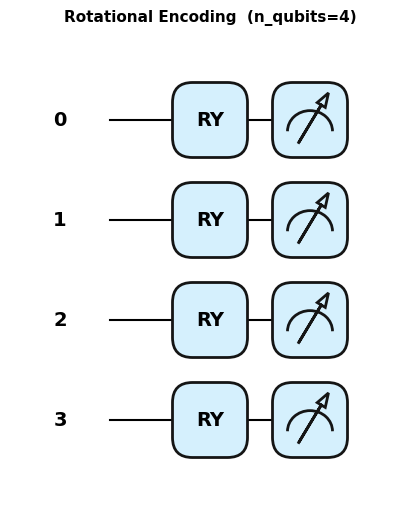

  Circuit depth for Rotational: 1

=== SimpleAngle ===


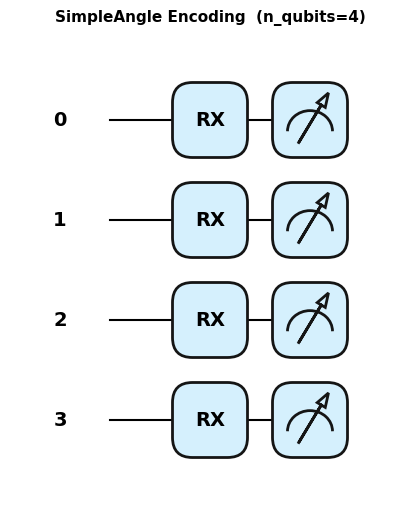

  Circuit depth for SimpleAngle: 1

=== Pi4Angle ===


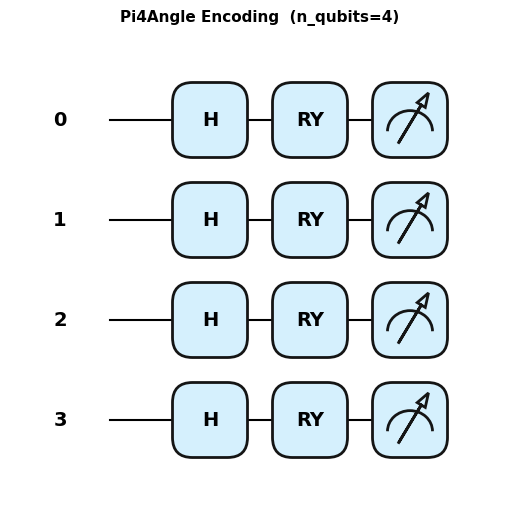

  Circuit depth for Pi4Angle: 2

=== EntangledAngle ===


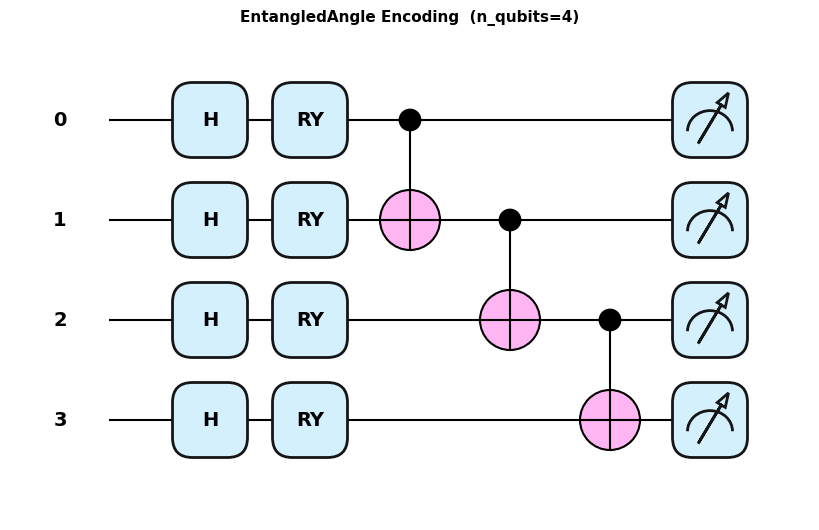

  Circuit depth for EntangledAngle: 5

=== Basis ===


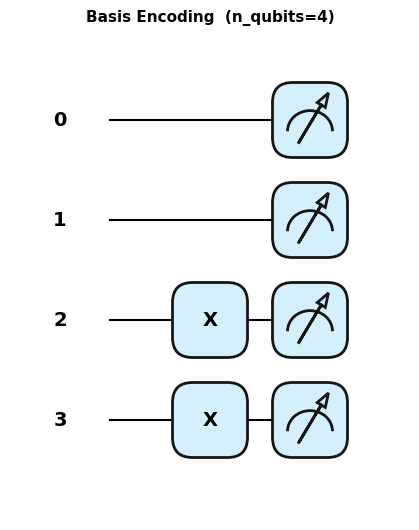

  Circuit depth for Basis: 1

=== Amplitude ===


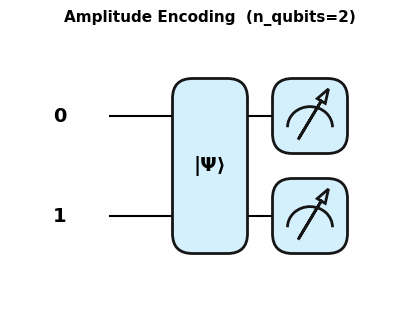

  Circuit depth for Amplitude: 1

=== DenseAngle ===


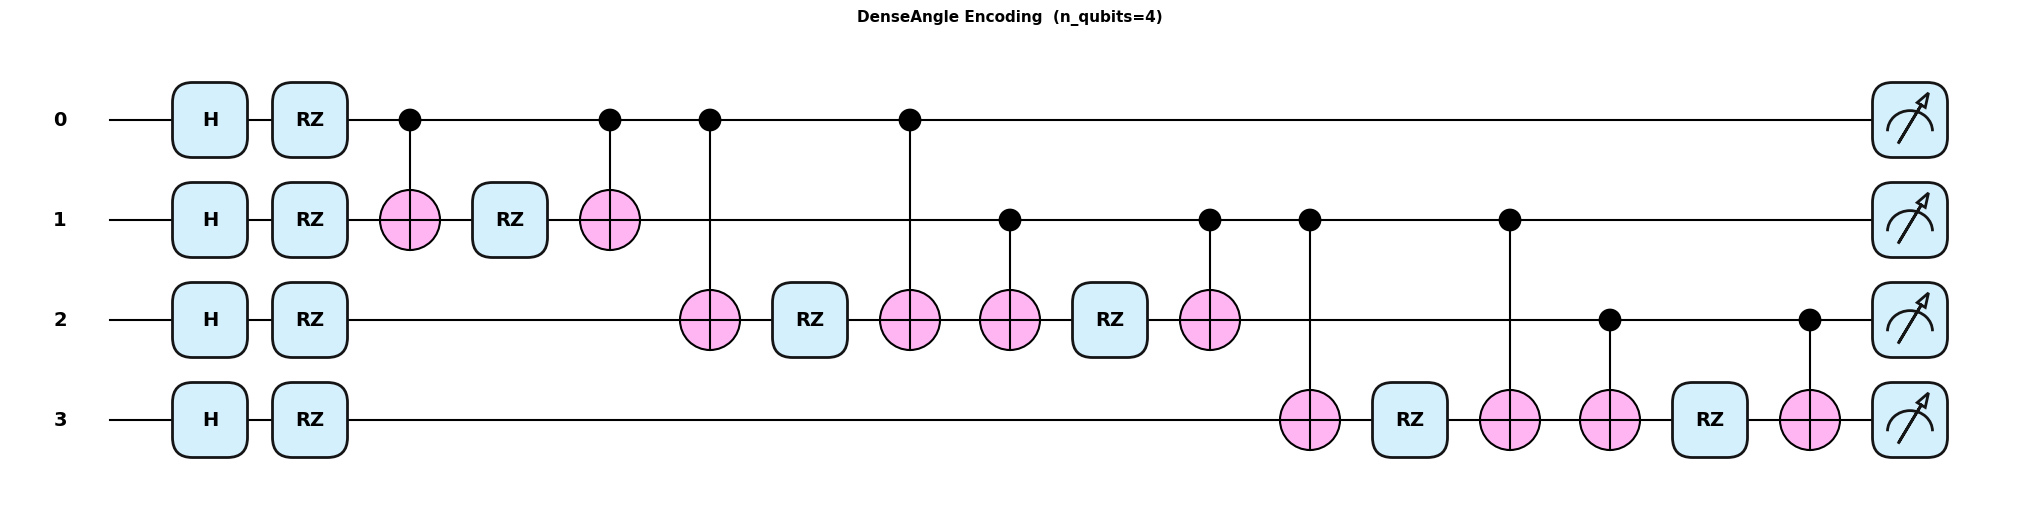

  Circuit depth for DenseAngle: 17

=== ShotBased ===


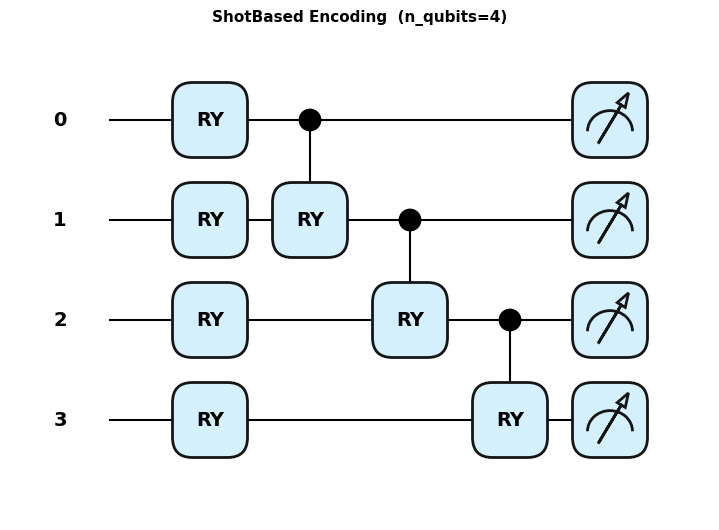

  Circuit depth for ShotBased: 4

=== FRQI ===


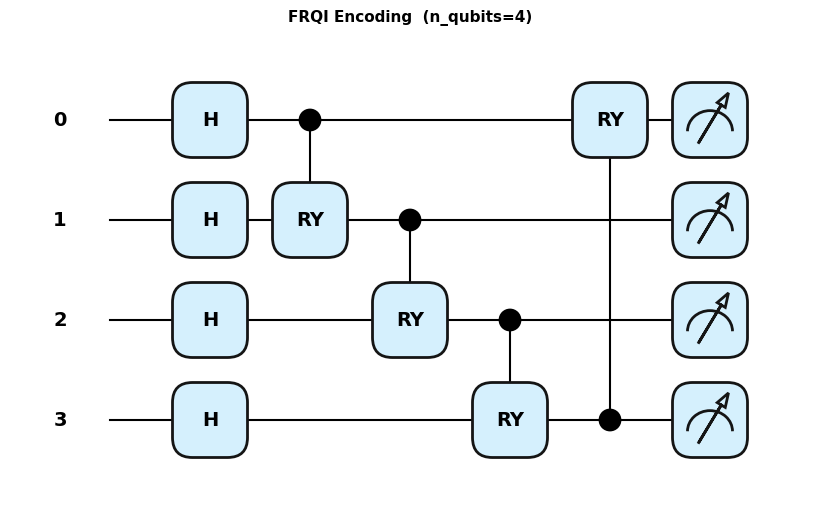

  Circuit depth for FRQI: 5

=== NEQR ===


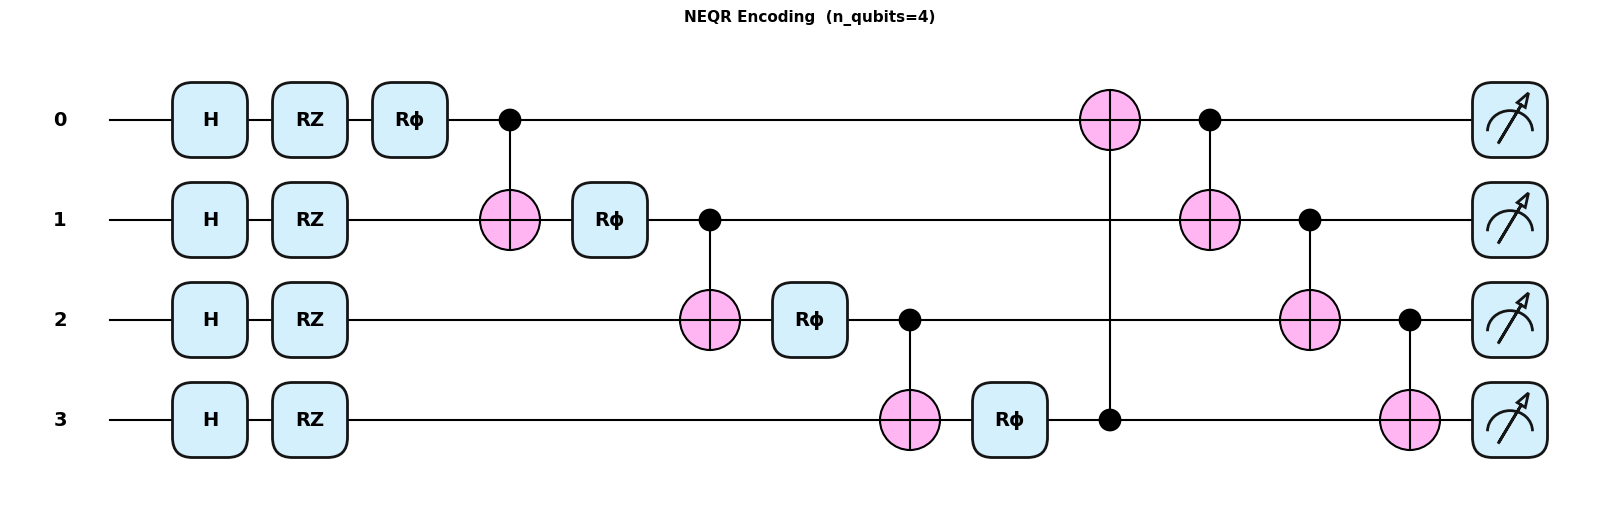

  Circuit depth for NEQR: 13

=== IQP ===


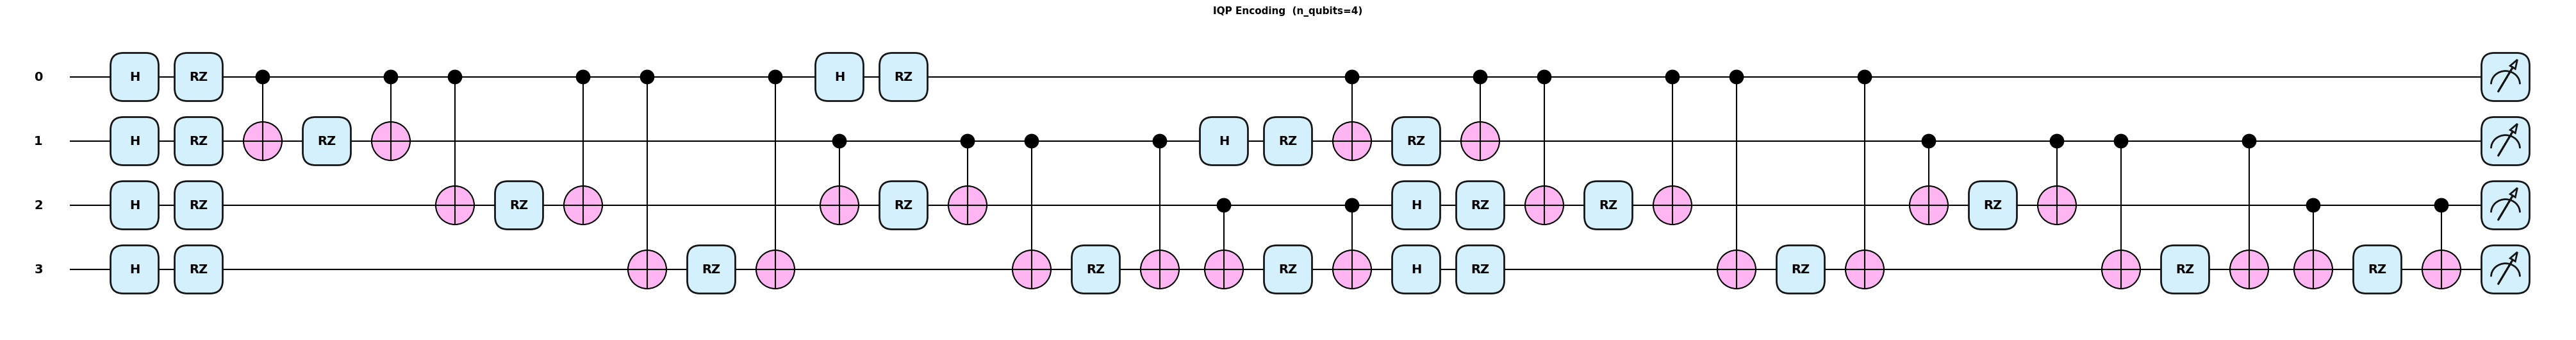

  Circuit depth for IQP: 31

=== QHE ===


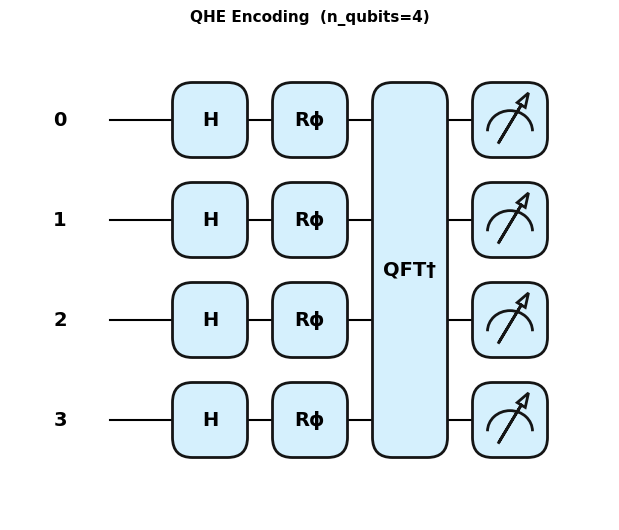

  Circuit depth for QHE: 3

=== Hamiltonian ===


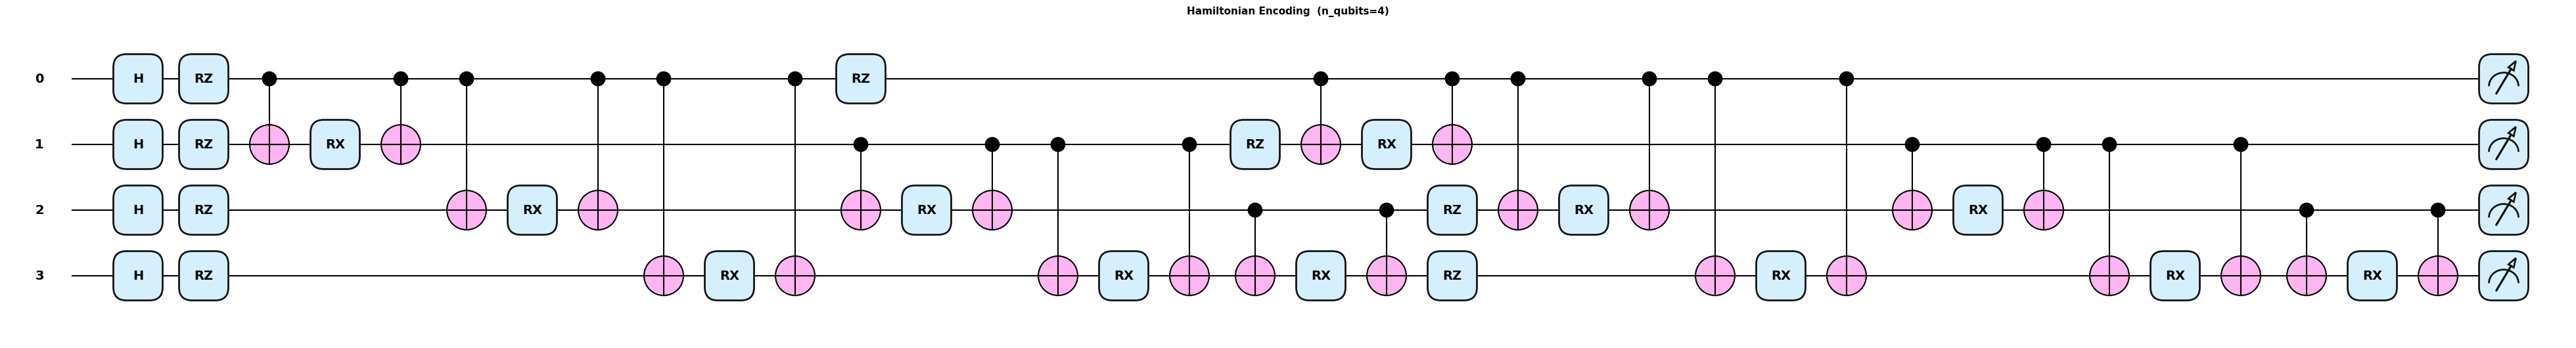

  Circuit depth for Hamiltonian: 30

=== GraphEncoding ===


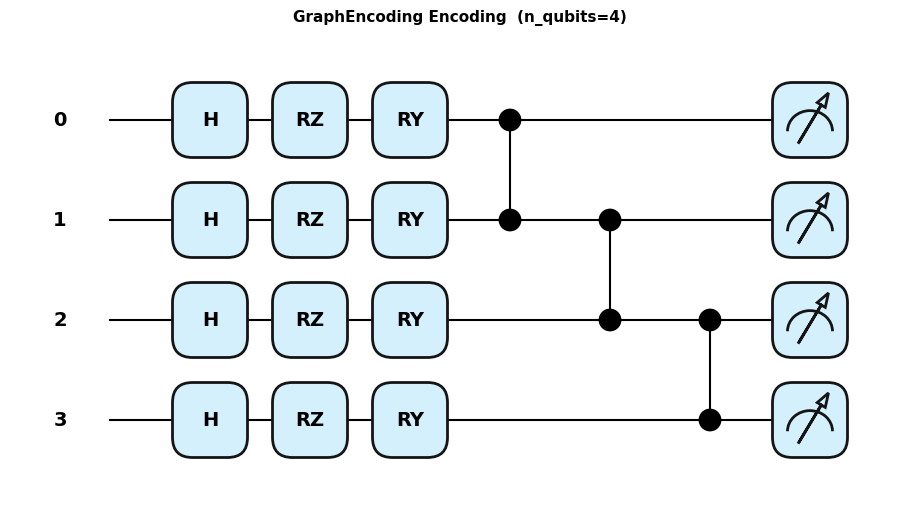

  Circuit depth for GraphEncoding: 6

=== AQHE_LogHelix ===


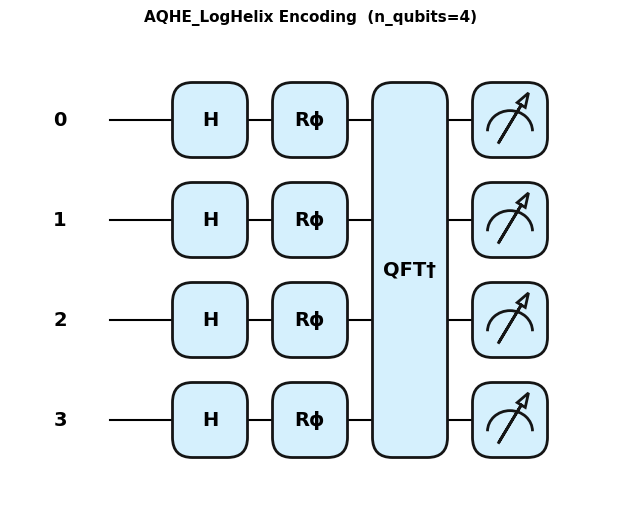

  Circuit depth for AQHE_LogHelix: 3

=== AQHE_FibSpiral ===


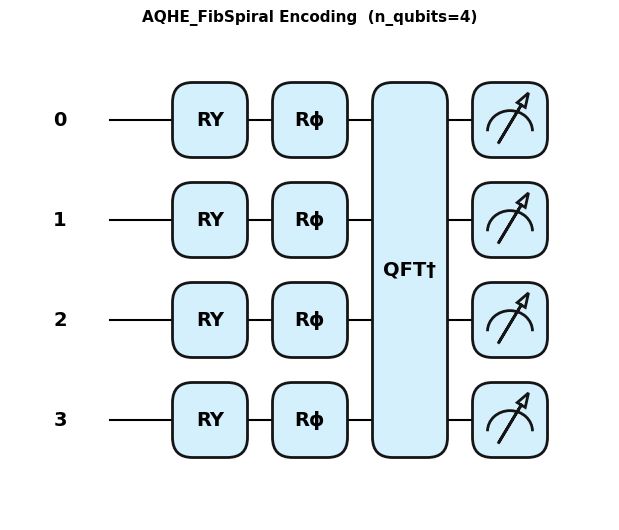

  Circuit depth for AQHE_FibSpiral: 3

=== AQHE_DualEnc ===


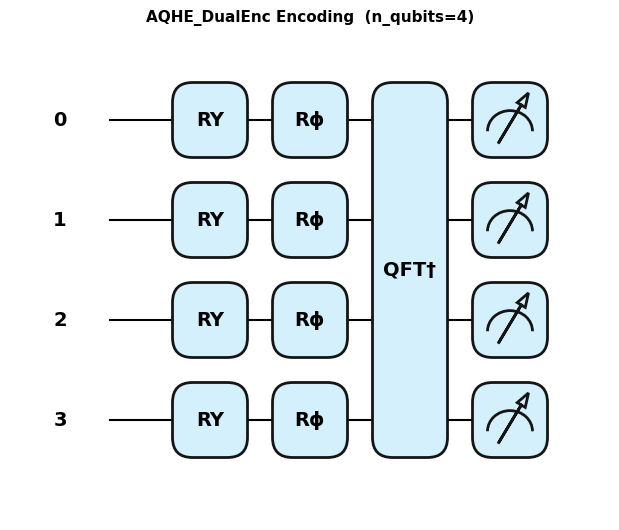

  Circuit depth for AQHE_DualEnc: 3


In [9]:
def draw_circuit(enc_name, enc_fn, n_qubits=4, feature_dim=4):
    # Amplitude and AQHE variants may use fewer/different qubits
    if enc_name == "Amplitude":
        n_draw = max(1, int(np.ceil(np.log2(feature_dim))))
    elif enc_name in ("QHE", "AQHE_LogHelix", "AQHE_FibSpiral", "AQHE_DualEnc"):
        n_draw = n_qubits
    else:
        n_draw = n_qubits
    dev = get_device(n_draw)
    @qml.qnode(dev)
    def circuit(x):
        enc_fn(x, n_draw)
        return [qml.expval(qml.PauliZ(i)) for i in range(n_draw)]
    x_dummy = np.linspace(0.1, np.pi - 0.1, feature_dim)
    try:
        fig, ax = qml.draw_mpl(circuit, style="pennylane")(x_dummy)
        fig.suptitle(f"{enc_name} Encoding  (n_qubits={n_draw})", fontsize=11,
                     fontweight="bold", y=1.02)
        plt.tight_layout()
        safe_name = "".join(c if c.isalnum() or c in "_-" else "_" for c in enc_name)
        plt.savefig(OUTPUT_DIR / f"circuit_{safe_name}.png", dpi=130, bbox_inches="tight")
        plt.show()
        try:
            depth = qml.specs(circuit)(x_dummy)["resources"].depth
            print(f"  Circuit depth for {enc_name}: {depth}")
        except Exception:
            print(f"  Circuit depth for {enc_name}: (unavailable)")
    except Exception as e:
        print(f"  [draw failed for {enc_name}]: {e}")

for name, fn in ENCODING_FNS.items():
    print(f"\n=== {name} ===")
    draw_circuit(name, fn)


## 4 · Quantum Kernel (Parallelized)

Parallelized kernel computation via `joblib`. Falls back to serial automatically.
For multiclass SVM: `OneVsRestClassifier(SVC(kernel='precomputed', C=1.0))`.


In [10]:
def _kernel_row_worker(i_start, i_end, X1, X2, enc_fn, n_qubits, symmetric):
    dev = get_device(n_qubits)
    @qml.qnode(dev)
    def kernel_circuit(x1, x2):
        enc_fn(x1, n_qubits)
        qml.adjoint(enc_fn)(x2, n_qubits)
        return qml.probs(wires=range(n_qubits))
    n2 = len(X2)
    out = []
    for i in range(i_start, i_end):
        row = np.zeros(n2)
        jstart = i + 1 if symmetric else 0
        if symmetric:
            row[i] = 1.0
        for j in range(jstart, n2):
            try:
                row[j] = kernel_circuit(X1[i], X2[j])[0]
            except Exception:
                row[j] = 0.0
        out.append((i, row))
    return out


def build_kernel_matrix(X1, X2, enc_fn, n_qubits, symmetric=False, n_jobs=N_JOBS, verbose=False):
    """Quantum kernel matrix, parallelized. symmetric=True for train-train (~2x faster)."""    
    n1, n2 = len(X1), len(X2)
    n_workers = n_jobs if n_jobs and n_jobs > 0 else max(1, os.cpu_count() or 1)
    n_workers = max(1, min(n_workers, n1))
    t0 = time.time()
    try:
        if n_workers > 1:
            chunk = max(1, n1 // n_workers + (1 if n1 % n_workers else 0))
            chunks = [(s, min(s + chunk, n1)) for s in range(0, n1, chunk)]
            results = Parallel(n_jobs=n_workers, prefer="processes")(
                delayed(_kernel_row_worker)(s, e, X1, X2, enc_fn, n_qubits, symmetric)
                for s, e in chunks
            )
        else:
            results = [_kernel_row_worker(0, n1, X1, X2, enc_fn, n_qubits, symmetric)]
    except Exception as e:
        print(f"    [parallel kernel failed: {e} -- falling back to serial]")
        results = [_kernel_row_worker(0, n1, X1, X2, enc_fn, n_qubits, symmetric)]
    K = np.zeros((n1, n2))
    for chunk_res in results:
        for i, row in chunk_res:
            K[i, :] = row
    if symmetric:
        K = np.triu(K) + np.triu(K, 1).T
    if verbose:
        print(f"    kernel {n1}x{n2} (symmetric={symmetric}) in {time.time()-t0:.1f}s")
    return K


def estimate_kernel_eta(enc_fn, n_qubits, n_train, n_test, n_jobs=N_JOBS, n_calib=6):
    """Calibrate real per-pair cost and project ETA."""    
    dev = get_device(n_qubits)
    @qml.qnode(dev)
    def kc(x1, x2):
        enc_fn(x1, n_qubits)
        qml.adjoint(enc_fn)(x2, n_qubits)
        return qml.probs(wires=range(n_qubits))
    x_dummy = np.linspace(0.1, np.pi - 0.1, max(4, n_qubits))
    t0 = time.time()
    for _ in range(n_calib):
        try:
            kc(x_dummy, x_dummy)[0]
        except Exception:
            pass
    sec_per_eval = (time.time() - t0) / n_calib
    pairs_tr = n_train * (n_train + 1) // 2
    pairs_te = n_test * n_train
    n_workers = n_jobs if n_jobs and n_jobs > 0 else max(1, os.cpu_count() or 1)
    eff = min(n_workers, max(1, os.cpu_count() or 1)) * 0.7 if n_workers > 1 else 1
    eta_sec = (pairs_tr + pairs_te) * sec_per_eval / max(eff, 1)
    return eta_sec, sec_per_eval


def fit_multiclass_svm_kernel(K_tr, K_te, y_tr, y_te):
    """Fit OneVsRest SVM on precomputed kernels; return test accuracy."""    # Sanitize kernel
    K_tr = np.nan_to_num(K_tr, nan=0.0, posinf=1.0, neginf=0.0)
    K_te = np.nan_to_num(K_te, nan=0.0, posinf=1.0, neginf=0.0)
    K_tr = (K_tr + K_tr.T) / 2
    np.fill_diagonal(K_tr, 1.0)
    svm = OneVsRestClassifier(SVC(kernel="precomputed", C=1.0))
    svm.fit(K_tr, y_tr)
    preds = svm.predict(K_te)
    return accuracy_score(y_te, preds)


print("Parallel kernel builder + multiclass SVM defined.")


Parallel kernel builder + multiclass SVM defined.


## 5 · Variational Quantum Classifier (VQC) — 2-layer, Multiclass

VQC uses **2 StronglyEntanglingLayers** (reduced from 6 — see fixes below).
For multiclass: measures `expval(PauliZ(i))` on each qubit, applies softmax,
and trains with **mini-batch Adam** and cross-entropy loss for K-class classification.

**v11 VQC fixes (all caused near-chance accuracy in v10 graphs):**
- **Barren plateau**: 6 layers × 6 qubits → gradient variance ~10⁻¹¹ → reduced to 2 layers
- **Optimizer**: Vanilla GD → Adam (adaptive lr handles tiny gradients)
- **Mini-batching**: Full 1875-sample cost per step → random batch of 32 per step
- **Weight init**: Uniform[-π,π] (deep in plateau) → N(0,0.01) (near identity gate)


In [11]:
import pennylane.numpy as pnp
from math import ceil

def build_vqc_multiclass(enc_fn, n_qubits, n_classes, n_layers=VQC_LAYERS):
    """Build a multiclass VQC with enc_fn closed over (not passed as arg).
    Uses default.qubit + parameter-shift for correct autograd gradients.
    """
    dev = qml.device("default.qubit", wires=n_qubits)
    n_params = n_layers * n_qubits * 3

    @qml.qnode(dev, interface="autograd", diff_method="parameter-shift")
    def vqc_circuit(x, weights):
        enc_fn(x, n_qubits)
        w = weights.reshape(n_layers, n_qubits, 3)
        qml.StronglyEntanglingLayers(w, wires=range(n_qubits))
        return tuple(qml.expval(qml.PauliZ(i)) for i in range(n_qubits))

    return vqc_circuit, n_params


def _softmax(z):
    z = pnp.array(z)
    z = z - pnp.max(z, axis=-1, keepdims=True)
    e = pnp.exp(z)
    return e / pnp.sum(e, axis=-1, keepdims=True)


def train_vqc_multiclass(enc_fn, Xtr, ytr, Xte, yte,
                          n_qubits=N_QUBITS, n_layers=VQC_LAYERS,
                          n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
                          lr=STEP_SIZE, verbose=True):
    """Train multiclass VQC.

    Train/val/test protocol
    -----------------------
    Xtr/ytr are split 80/20 into train and validation INSIDE this function.
    Xte/yte (the test set) are kept COMPLETELY UNSEEN during training.
    After all epochs are done, the final weights are evaluated ONCE on Xte.

    Epoch definition (fixed)
    ------------------------
    One epoch = ceil(n_train / batch_size) gradient steps, i.e. a full pass
    through the training data in random mini-batches.
    Previously there was 1 step per epoch, giving only 30 weight updates total
    for 30 epochs. With n_train=360 and batch_size=32 this is now 12 steps/epoch
    → 360 total updates for 30 epochs, 15× more training signal.
    """
    n_classes = len(np.unique(np.concatenate([ytr, yte])))

    # ── 1. Carve out validation set (20% of Xtr) ────────────────────────────
    val_size   = max(1, int(0.2 * len(Xtr)))
    val_idx    = rng.choice(len(Xtr), size=val_size, replace=False)
    train_mask = np.ones(len(Xtr), dtype=bool)
    train_mask[val_idx] = False

    Xval, yval   = Xtr[val_idx],    ytr[val_idx]
    Xtr2, ytr2   = Xtr[train_mask], ytr[train_mask]
    n_train      = len(Xtr2)
    steps_per_ep = max(1, ceil(n_train / batch_size))

    if verbose:
        print(f"  Split: {n_train} train | {val_size} val | {len(Xte)} test (unseen)")
        print(f"  Steps/epoch: {steps_per_ep}  (batch={batch_size})")

    # ── 2. Build circuit and initialise weights ──────────────────────────────
    vqc, n_params = build_vqc_multiclass(enc_fn, n_qubits, n_classes, n_layers)
    weights = pnp.array(rng.normal(0, 0.01, n_params), requires_grad=True)
    opt     = qml.AdamOptimizer(stepsize=lr)

    tr_acc_hist, val_acc_hist = [], []

    # ── 3. Helpers ───────────────────────────────────────────────────────────
    def _get_logits(X, w):
        raw   = np.array([np.array(vqc(x, w)) for x in X])   # [N, n_qubits]
        n_out = raw.shape[1]
        if n_out >= n_classes:
            return raw[:, :n_classes]
        pad = np.full((raw.shape[0], n_classes - n_out), -1.0)
        return np.concatenate([raw, pad], axis=1)

    def _predict(X, w):
        logits = _get_logits(X, w)
        logits = logits - np.max(logits, axis=1, keepdims=True)
        exp_l  = np.exp(logits)
        proba  = exp_l / np.sum(exp_l, axis=1, keepdims=True)
        return np.argmax(proba, axis=1)

    # ── 4. Training loop ─────────────────────────────────────────────────────
    for epoch in range(n_epochs):
        # Shuffle training data for this epoch
        perm = rng.permutation(n_train)
        Xtr2_shuf, ytr2_shuf = Xtr2[perm], ytr2[perm]

        epoch_loss = 0.0
        for step in range(steps_per_ep):
            s = step * batch_size
            e = min(s + batch_size, n_train)
            X_batch = Xtr2_shuf[s:e]
            y_batch = ytr2_shuf[s:e]

            # Close over batch so w is the only differentiable arg
            def cost(w):
                raw   = pnp.stack([vqc(x, w) for x in X_batch])
                n_out = raw.shape[1]
                if n_out >= n_classes:
                    logits_cls = raw[:, :n_classes]
                else:
                    pad        = pnp.zeros((raw.shape[0], n_classes - n_out))
                    logits_cls = pnp.concatenate([raw, pad], axis=1)
                proba   = _softmax(logits_cls)
                one_hot = pnp.eye(n_classes)[y_batch]
                return -pnp.mean(pnp.sum(one_hot * pnp.log(proba + 1e-9), axis=1))

            weights, loss_val = opt.step_and_cost(cost, weights)
            epoch_loss += float(loss_val)

        # Evaluate on train and val (NOT test)
        tr_acc  = accuracy_score(ytr2,  _predict(Xtr2, weights))
        val_acc = accuracy_score(yval,  _predict(Xval, weights))
        tr_acc_hist.append(tr_acc)
        val_acc_hist.append(val_acc)

        if verbose and (epoch + 1) % 5 == 0:
            avg_loss = epoch_loss / steps_per_ep
            print(f"  Epoch {epoch+1:3d}/{n_epochs}  loss={avg_loss:.4f}  "
                  f"tr_acc={tr_acc:.3f}  val_acc={val_acc:.3f}")

    # ── 5. Final evaluation on UNSEEN test set (once, after all training) ────
    te_preds = _predict(Xte, weights)
    te_acc   = accuracy_score(yte, te_preds)
    if verbose:
        print(f"  → Final test acc (unseen): {te_acc:.4f}")

    # Return val_acc_hist as the "te_hist" slot so existing plot code works,
    # and store final test acc separately in the last element
    # te_hist[-1] used by benchmark cell for vqc_acc -> use actual te_acc
    te_hist_out = val_acc_hist[:-1] + [te_acc]   # all val, last point = real test

    return weights, tr_acc_hist, te_hist_out


print(f"VQC helpers defined (v11 — train/val/test split, full epoch pass).")
print(f"  Device       : default.qubit + diff_method=parameter-shift")
print(f"  Optimizer    : AdamOptimizer(lr={STEP_SIZE})")
print(f"  VQC_LAYERS   : {VQC_LAYERS}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Steps/epoch  : ceil(n_train / batch_size)  [full data pass per epoch]")
print(f"  Val split    : 20% of Xtr  [used for epoch monitoring]")
print(f"  Test set     : evaluated ONCE after all epochs complete")
print(f"  Weight init  : N(0, 0.01)")

VQC helpers defined (v11 — train/val/test split, full epoch pass).
  Device       : default.qubit + diff_method=parameter-shift
  Optimizer    : AdamOptimizer(lr=0.01)
  VQC_LAYERS   : 2
  Batch size   : 32
  Steps/epoch  : ceil(n_train / batch_size)  [full data pass per epoch]
  Val split    : 20% of Xtr  [used for epoch monitoring]
  Test set     : evaluated ONCE after all epochs complete
  Weight init  : N(0, 0.01)


## 6 · Main Benchmark: All Encodings × All Datasets (Multiclass SVM)

Prints calibrated ETA before running. Multiclass accuracy via OneVsRest SVM on quantum kernels.


In [ ]:
RUN_VQC    = True   # set True for real epoch curves in section 7 (much slower)
RUN_KERNEL = True

# ETA calibration
print("Calibrating runtime estimate for the main benchmark ...")
sample_ds = list(data.values())[0]
n_train_est, n_test_est = len(sample_ds[0]), len(sample_ds[1])
total_eta = 0
for enc_name, enc_fn in ENCODING_FNS.items():
    try:
        eta, sec_per_eval = estimate_kernel_eta(enc_fn, N_QUBITS, n_train_est, n_test_est)
        total_eta += eta * len(data)
    except Exception as e:
        print(f"  [{enc_name}] ETA calibration failed: {e}")
print(f"  -> Estimated total: ~{total_eta/60:.1f} min (~{total_eta/3600:.2f} hr) "
      f"using {N_JOBS if N_JOBS>0 else N_CORES} worker(s)")
print(f"  -> {len(ENCODING_FNS)} encodings x {len(data)} datasets")

results = {}
t_start_all = time.time()

for ds_name, (Xtr, Xte, ytr, yte) in data.items():
    results[ds_name] = {}
    n_cls = len(np.unique(np.concatenate([ytr, yte])))
    print(f"\n{'='*65}")
    print(f"  DATASET: {ds_name}  (train={len(Xtr)}, test={len(Xte)}, {n_cls} classes)  [{data_source[ds_name]}]")
    print(f"{'='*65}")

    for enc_name, enc_fn in ENCODING_FNS.items():
        print(f"\n  Encoding: {enc_name}")
        row = {}

        if RUN_KERNEL:
            try:
                t0 = time.time()
                K_tr = build_kernel_matrix(Xtr, Xtr, enc_fn, N_QUBITS, symmetric=True)
                K_te = build_kernel_matrix(Xte, Xtr, enc_fn, N_QUBITS, symmetric=False)
                svm_acc = fit_multiclass_svm_kernel(K_tr, K_te, ytr, yte)
                row["svm_acc"] = svm_acc
                print(f"    SVM (OneVsRest) acc = {svm_acc:.3f}  ({time.time()-t0:.1f}s)")
            except Exception as e:
                print(f"    [FAILED: {e}]")
                row["svm_acc"] = np.nan
        else:
            row["svm_acc"] = np.nan

        if RUN_VQC:
            try:
                _, tr_h, te_h = train_vqc_multiclass(enc_fn, Xtr, ytr, Xte, yte, batch_size=BATCH_SIZE, verbose=False)
                row["vqc_acc"] = te_h[-1]; row["tr_hist"] = tr_h; row["te_hist"] = te_h
            except Exception as e:
                print(f"    [VQC FAILED: {e}]")
                row["vqc_acc"] = np.nan; row["tr_hist"] = []; row["te_hist"] = []
        else:
            row["vqc_acc"] = np.nan; row["tr_hist"] = []; row["te_hist"] = []

        results[ds_name][enc_name] = row

total_elapsed = time.time() - t_start_all
print(f"\n\nBenchmark complete in {total_elapsed/60:.1f} min.")
if RUN_VQC:
    print(f"  (Note: ETA above was SVM-only. VQC adds ~{total_elapsed/60 - total_eta/60:.0f} min extra.)")

# Print summary table — SVM + VQC final acc
has_vqc = RUN_VQC and any(
    results.get(ds, {}).get(enc, {}).get("vqc_acc") is not None
    and not np.isnan(results.get(ds, {}).get(enc, {}).get("vqc_acc", np.nan))
    for ds in data for enc in ENCODING_FNS
)

print("\n" + "="*90)
print("SUMMARY (SVM Accuracy)" + ("  |  VQC final test acc (last epoch)" if has_vqc else ""))
print("="*90)
enc_list = list(ENCODING_FNS.keys())
ds_list  = list(data.keys())

if has_vqc:
    header = f"{'Encoding':<18}" + "".join(f"{'SVM_'+ds[:8]:>16}" for ds in ds_list) \
           + "".join(f"{'VQC_'+ds[:8]:>16}" for ds in ds_list)
else:
    header = f"{'Encoding':<18}" + "".join(f"{ds:>14}" for ds in ds_list)
print(header)
print("-"*90)

for enc in enc_list:
    row_str = f"{enc:<18}"
    for ds in ds_list:
        val = results.get(ds, {}).get(enc, {}).get("svm_acc", np.nan)
        row_str += f"{'N/A':>14}" if np.isnan(val) else f"{val:>14.3f}"
    if has_vqc:
        for ds in ds_list:
            val = results.get(ds, {}).get(enc, {}).get("vqc_acc", np.nan)
            row_str += f"{'N/A':>16}" if (val is None or np.isnan(val)) else f"{val:>16.3f}"
    print(row_str)


Calibrating runtime estimate for the main benchmark ...
  -> Estimated total: ~139.8 min (~2.33 hr) using 16 worker(s)
  -> 17 encodings x 3 datasets

  DATASET: MNIST_5cls  (train=450, test=150, 5 classes)  [REAL]

  Encoding: Rotational
    SVM (OneVsRest) acc = 0.873  (276.6s)

  Encoding: SimpleAngle
    SVM (OneVsRest) acc = 0.873  (370.8s)

  Encoding: Pi4Angle
    SVM (OneVsRest) acc = 0.860  (366.9s)

  Encoding: EntangledAngle
    SVM (OneVsRest) acc = 0.873  (405.3s)

  Encoding: Basis
    SVM (OneVsRest) acc = 0.507  (33.9s)

  Encoding: Amplitude
    SVM (OneVsRest) acc = 0.713  (61.9s)

  Encoding: DenseAngle
    SVM (OneVsRest) acc = 0.887  (127.3s)

  Encoding: ShotBased
    SVM (OneVsRest) acc = 0.720  (544.7s)

  Encoding: FRQI
    SVM (OneVsRest) acc = 0.900  (659.6s)

  Encoding: NEQR
    SVM (OneVsRest) acc = 0.893  (340.2s)

  Encoding: IQP
    SVM (OneVsRest) acc = 0.860  (923.1s)

  Encoding: QHE
    SVM (OneVsRest) acc = 0.873  (237.9s)

  Encoding: Hamiltonian


## 7 · Accuracy per Epoch (VQC — Multiclass)

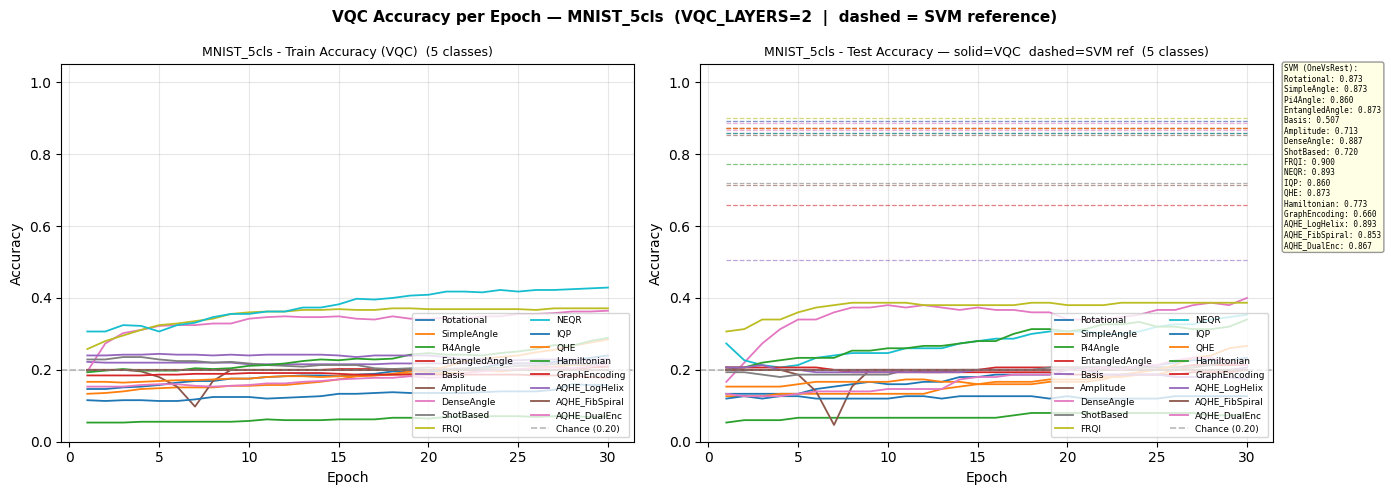

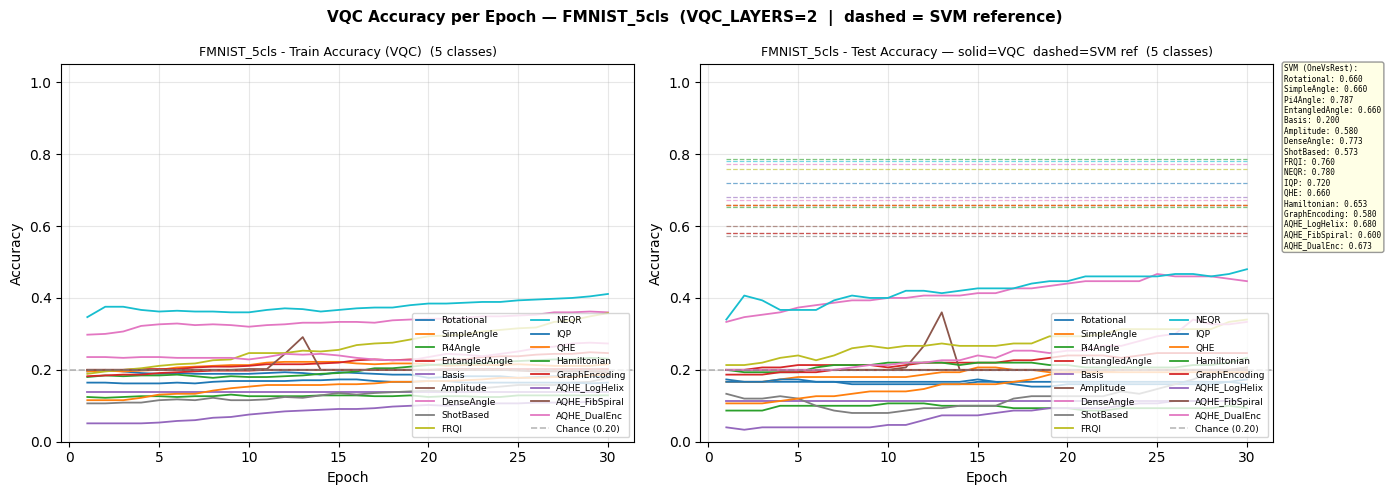

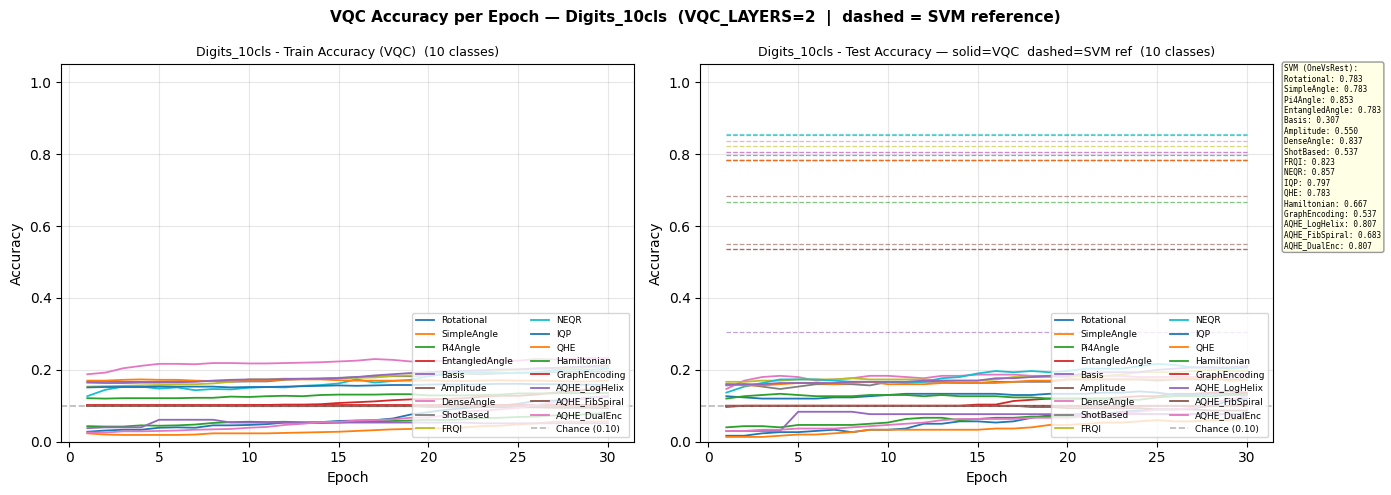

In [34]:
def plot_accuracy_curves(results, dataset):
    ds_res = results.get(dataset, {})
    has_vqc = any(len(v.get("te_hist", [])) > 0 for v in ds_res.values())
    n_cls = len(np.unique(np.concatenate([data[dataset][2], data[dataset][3]])))
    chance = 1.0 / n_cls

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    enc_names = list(ds_res.keys())

    for i, (enc_name, row) in enumerate(ds_res.items()):
        color = color_cycle[i % len(color_cycle)]
        svm_acc = row.get("svm_acc", None)   # horizontal SVM reference per encoding
        tr_h    = row.get("tr_hist", [])
        te_h    = row.get("te_hist", [])

        if has_vqc and len(te_h) > 0:
            epochs = np.arange(1, len(te_h) + 1)
            axes[0].plot(epochs, tr_h, label=enc_name, linewidth=1.3, color=color)
            axes[1].plot(epochs, te_h, label=enc_name, linewidth=1.3, color=color)

            # Overlay SVM accuracy as a dashed horizontal line on the test panel
            if svm_acc is not None:
                axes[1].hlines(svm_acc, xmin=1, xmax=len(te_h),
                               colors=color, linestyles='dashed',
                               linewidth=0.9, alpha=0.6)
        else:
            # VQC not run — plot SVM acc as a single marker/flat line on both panels
            if svm_acc is not None:
                for ax in axes:
                    ax.hlines(svm_acc, xmin=1, xmax=N_EPOCHS,
                              colors=color, linestyles='solid',
                              linewidth=1.4, label=enc_name, alpha=0.85)

    # Chance line
    for ax, title in zip(axes, ["Train Accuracy (VQC)", "Test Accuracy — solid=VQC  dashed=SVM ref"]):
        ax.axhline(chance, color="gray", linestyle="--", linewidth=1.2,
                   alpha=0.55, label=f"Chance ({chance:.2f})")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.set_title(f"{dataset} - {title}  ({n_cls} classes)", fontsize=9)
        ax.legend(fontsize=6.5, ncol=2, loc="lower right")
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)

    # Add SVM summary text box on the right panel
    svm_lines = [f"{enc}: {row.get('svm_acc', float('nan')):.3f}"
                 for enc, row in ds_res.items() if row.get('svm_acc') is not None]
    if svm_lines:
        summary_txt = "SVM (OneVsRest):\n" + "\n".join(svm_lines)
        axes[1].text(1.02, 1.0, summary_txt, transform=axes[1].transAxes,
                     fontsize=5.5, verticalalignment='top',
                     fontfamily='monospace',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                               alpha=0.8, edgecolor='gray'))

    fig.suptitle(
        f"VQC Accuracy per Epoch — {dataset}  "
        f"(VQC_LAYERS={VQC_LAYERS}{'  |  dashed = SVM reference' if has_vqc else '  |  SVM-only (VQC not run)'})",
        fontsize=11, fontweight="bold"
    )
    plt.tight_layout()
    safe_ds = dataset.replace("/", "_").replace(" ", "_")
    plt.savefig(OUTPUT_DIR / f"epoch_curves_{safe_ds}.png", dpi=140, bbox_inches="tight")
    plt.show()

for ds in DATASETS:
    plot_accuracy_curves(results, ds)

## 8 · Qubit Count Variation (2 → 8, All Encodings)

Tests every encoding across the full qubit range on MNIST_5cls.
Note: Amplitude encoding's effective qubit count is fixed by feature dimensionality.


Calibrating runtime estimate for qubit sweep on MNIST_5cls (5 classes) ...
  -> Estimated total: ~137.6 min (~2.29 hr)

Qubit sweep on MNIST_5cls ...
  n_qubits = 2
    Rotational         -> 0.540
    SimpleAngle        -> 0.540
    Pi4Angle           -> 0.493
    EntangledAngle     -> 0.540
    Basis              -> 0.347
    Amplitude          -> 0.713
    DenseAngle         -> 0.507
    ShotBased          -> 0.540
    FRQI               -> 0.520
    NEQR               -> 0.473
    IQP                -> 0.553
    QHE                -> 0.540
    Hamiltonian        -> 0.560
    GraphEncoding      -> 0.200
    AQHE_LogHelix      -> 0.560
    AQHE_FibSpiral     -> 0.573
    AQHE_DualEnc       -> 0.573
  n_qubits = 3
    Rotational         -> 0.740
    SimpleAngle        -> 0.740
    Pi4Angle           -> 0.740
    EntangledAngle     -> 0.740
    Basis              -> 0.420
    Amplitude          -> 0.713
    DenseAngle         -> 0.707
    ShotBased          -> 0.700
    FRQI            

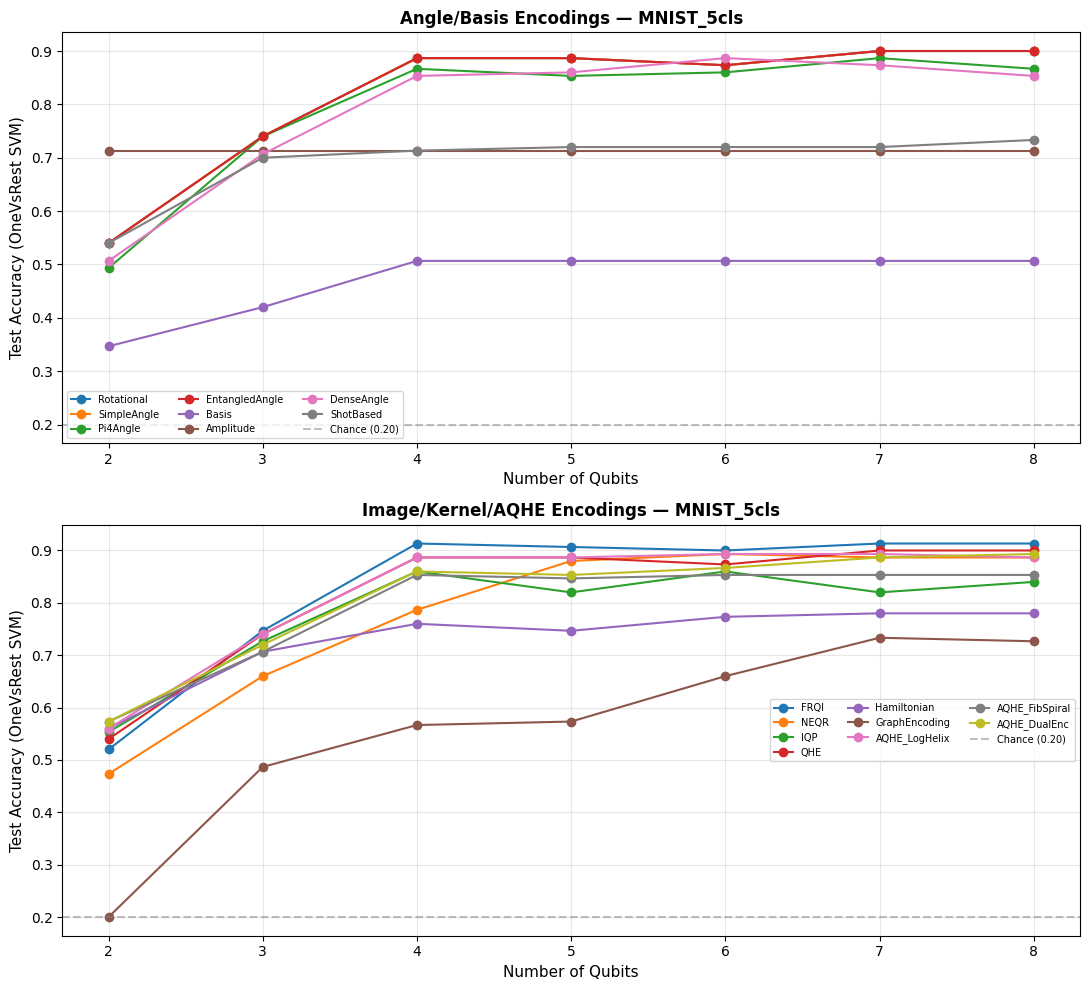

Saved: c:\Users\MANTAVYA\Downloads\qml_outputs_v10\qubit_sweep.png


In [13]:
SWEEP_ENC = list(ENCODING_FNS.keys())
SWEEP_DS  = "MNIST_5cls"

Xtr_sw, Xte_sw, ytr_sw, yte_sw = data[SWEEP_DS]
n_cls_sw = len(np.unique(np.concatenate([ytr_sw, yte_sw])))

print(f"Calibrating runtime estimate for qubit sweep on {SWEEP_DS} ({n_cls_sw} classes) ...")
total_eta_sweep = 0
for nq in QUBIT_SWEEP:
    for enc_name in SWEEP_ENC:
        try:
            eta, _ = estimate_kernel_eta(ENCODING_FNS[enc_name], nq, len(Xtr_sw), len(Xte_sw))
            total_eta_sweep += eta
        except Exception:
            pass
print(f"  -> Estimated total: ~{total_eta_sweep/60:.1f} min (~{total_eta_sweep/3600:.2f} hr)\n")

qubit_results = {enc: [] for enc in SWEEP_ENC}

print(f"Qubit sweep on {SWEEP_DS} ...")
t_start_sweep = time.time()
for nq in QUBIT_SWEEP:
    print(f"  n_qubits = {nq}")
    for enc_name in SWEEP_ENC:
        enc_fn = ENCODING_FNS[enc_name]
        try:
            K_tr = build_kernel_matrix(Xtr_sw, Xtr_sw, enc_fn, nq, symmetric=True)
            K_te = build_kernel_matrix(Xte_sw, Xtr_sw, enc_fn, nq, symmetric=False)
            acc  = fit_multiclass_svm_kernel(K_tr, K_te, ytr_sw, yte_sw)
            qubit_results[enc_name].append(acc)
            print(f"    {enc_name:18s} -> {acc:.3f}")
        except Exception as e:
            qubit_results[enc_name].append(np.nan)
            print(f"    {enc_name:18s} -> FAILED: {e}")

print(f"\nQubit sweep done in {(time.time()-t_start_sweep)/60:.1f} min.")

# Plot — split into groups for readability
fig, axes = plt.subplots(2, 1, figsize=(11, 10))
groups = [
    ("Angle/Basis Encodings", ["Rotational","SimpleAngle","Pi4Angle","EntangledAngle","Basis","Amplitude","DenseAngle","ShotBased"]),
    ("Image/Kernel/AQHE Encodings", ["FRQI","NEQR","IQP","QHE","Hamiltonian","GraphEncoding","AQHE_LogHelix","AQHE_FibSpiral","AQHE_DualEnc"]),
]
chance = 1.0 / n_cls_sw
for ax, (title, group) in zip(axes, groups):
    for enc_name in group:
        if enc_name in qubit_results:
            vals = qubit_results[enc_name]
            ax.plot(QUBIT_SWEEP[:len(vals)], vals, marker="o", label=enc_name, linewidth=1.5)
    ax.axhline(chance, color="gray", linestyle="--", alpha=0.5, label=f"Chance ({chance:.2f})")
    ax.set_xlabel("Number of Qubits", fontsize=11)
    ax.set_ylabel("Test Accuracy (OneVsRest SVM)", fontsize=11)
    ax.set_title(f"{title} — {SWEEP_DS}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=7, ncol=3); ax.grid(alpha=0.3)
    ax.set_xticks(QUBIT_SWEEP)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "qubit_sweep.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved:", OUTPUT_DIR / "qubit_sweep.png")


## 9 · PCA Dimensionality Sensitivity Analysis

PCA dimension sensitivity (MNIST_5cls) ...
  [MNIST_5cls] REAL MNIST via tensorflow (600 samples, 5 classes)
  PCA= 2  n_qubits=2  Rotational         -> 0.627
  PCA= 2  n_qubits=2  QHE                -> 0.627
  PCA= 2  n_qubits=2  IQP                -> 0.633
  PCA= 2  n_qubits=2  Hamiltonian        -> 0.633
  [MNIST_5cls] REAL MNIST via tensorflow (600 samples, 5 classes)
  PCA= 4  n_qubits=4  Rotational         -> 0.760
  PCA= 4  n_qubits=4  QHE                -> 0.760
  PCA= 4  n_qubits=4  IQP                -> 0.773
  PCA= 4  n_qubits=4  Hamiltonian        -> 0.707
  [MNIST_5cls] REAL MNIST via tensorflow (600 samples, 5 classes)
  PCA= 6  n_qubits=6  Rotational         -> 0.940
  PCA= 6  n_qubits=6  QHE                -> 0.940
  PCA= 6  n_qubits=6  IQP                -> 0.867
  PCA= 6  n_qubits=6  Hamiltonian        -> 0.773
  [MNIST_5cls] REAL MNIST via tensorflow (600 samples, 5 classes)
  PCA= 8  n_qubits=6  Rotational         -> 0.913
  PCA= 8  n_qubits=6  QHE                ->

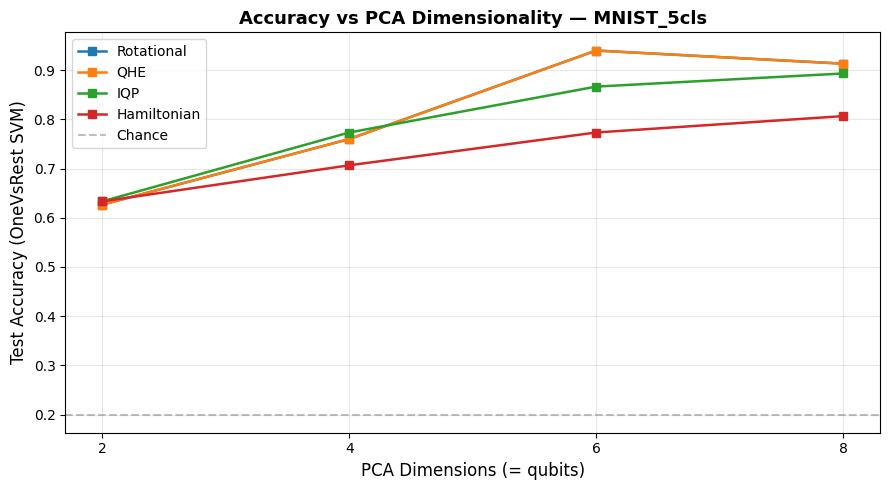

In [14]:
PCA_SWEEP_ENC = ["Rotational", "QHE", "IQP", "Hamiltonian"]
pca_results   = {enc: [] for enc in PCA_SWEEP_ENC}
pca_dim_used  = []

print("PCA dimension sensitivity (MNIST_5cls) ...")
for pdim in PCA_DIMS:
    Xtr_p, Xte_p, ytr_p, yte_p, _src = load_mnist_multiclass(pca_dim=pdim)
    pca_dim_used.append(pdim)
    nq = min(pdim, N_QUBITS)
    for enc_name in PCA_SWEEP_ENC:
        enc_fn = ENCODING_FNS[enc_name]
        try:
            K_tr = build_kernel_matrix(Xtr_p, Xtr_p, enc_fn, nq, symmetric=True)
            K_te = build_kernel_matrix(Xte_p, Xtr_p, enc_fn, nq, symmetric=False)
            acc  = fit_multiclass_svm_kernel(K_tr, K_te, ytr_p, yte_p)
            pca_results[enc_name].append(acc)
            print(f"  PCA={pdim:2d}  n_qubits={nq}  {enc_name:18s} -> {acc:.3f}")
        except Exception as e:
            pca_results[enc_name].append(np.nan)
            print(f"  PCA={pdim:2d}  n_qubits={nq}  {enc_name:18s} -> FAILED: {e}")

fig, ax = plt.subplots(figsize=(9, 5))
n_cls_pca = N_CLASSES
for enc_name in PCA_SWEEP_ENC:
    vals = pca_results[enc_name]
    ax.plot(pca_dim_used[:len(vals)], vals, marker="s", label=enc_name, linewidth=1.8)
ax.axhline(1.0 / n_cls_pca, color="gray", linestyle="--", alpha=0.5, label=f"Chance")
ax.set_xlabel("PCA Dimensions (= qubits)", fontsize=12)
ax.set_ylabel("Test Accuracy (OneVsRest SVM)", fontsize=12)
ax.set_title(f"Accuracy vs PCA Dimensionality — MNIST_{n_cls_pca}cls", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
ax.set_xticks(pca_dim_used)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca_sensitivity.png", dpi=140, bbox_inches="tight")
plt.show()


PCA=8 on 8 qubits — MNIST_5cls ...
  [MNIST_5cls] REAL MNIST via tensorflow (600 samples, 5 classes)
  Data: train=450, test=150, features=8, qubits=8
  PCA=8  n_qubits=8  Rotational         -> 0.913
  PCA=8  n_qubits=8  QHE                -> 0.913
  PCA=8  n_qubits=8  IQP                -> 0.907
  PCA=8  n_qubits=8  Hamiltonian        -> 0.760


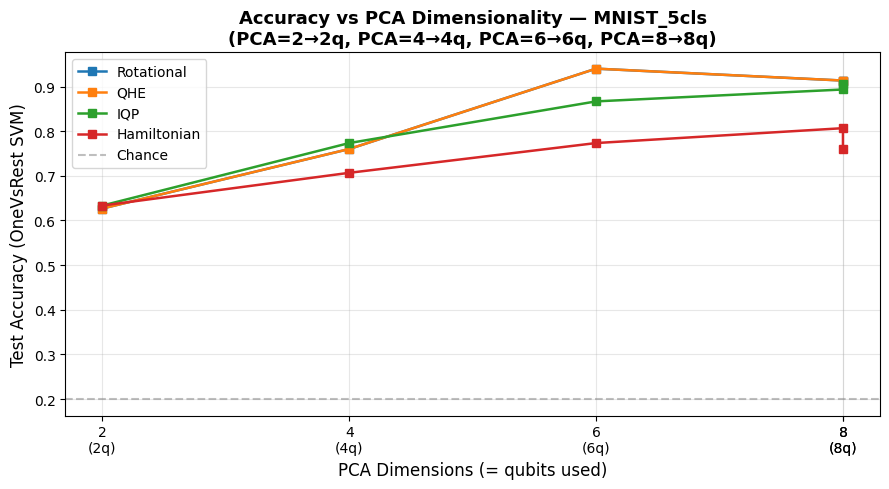


PCA=8 / 8-qubit results (vs PCA=6 / 6-qubit):
  Rotational          PCA=8/8q: 0.913  vs PCA=6/6q: 0.940  Δ=-0.027
  QHE                 PCA=8/8q: 0.913  vs PCA=6/6q: 0.940  Δ=-0.027
  IQP                 PCA=8/8q: 0.907  vs PCA=6/6q: 0.867  Δ=+0.040
  Hamiltonian         PCA=8/8q: 0.760  vs PCA=6/6q: 0.773  Δ=-0.013


In [15]:
# ── PCA=8 on 8 qubits — standalone cell (no re-run of 2/4/6) ──────────────
pca_dim = 8
n_q     = 8

print(f"PCA={pca_dim} on {n_q} qubits — MNIST_5cls ...")

# Load MNIST with 8 PCA dims using the same loader as cell 24
Xtr_p, Xte_p, ytr_p, yte_p, _src = load_mnist_multiclass(pca_dim=pca_dim)
print(f"  Data: train={len(Xtr_p)}, test={len(Xte_p)}, features={Xtr_p.shape[1]}, qubits={n_q}")

pca8_results = {}   # enc_name -> acc

for enc_name in PCA_SWEEP_ENC:
    enc_fn = ENCODING_FNS[enc_name]
    try:
        K_tr = build_kernel_matrix(Xtr_p, Xtr_p, enc_fn, n_q, symmetric=True)
        K_te = build_kernel_matrix(Xte_p, Xtr_p, enc_fn, n_q, symmetric=False)
        acc  = fit_multiclass_svm_kernel(K_tr, K_te, ytr_p, yte_p)
        pca8_results[enc_name] = acc
        print(f"  PCA={pca_dim}  n_qubits={n_q}  {enc_name:<18} -> {acc:.3f}")
    except Exception as e:
        pca8_results[enc_name] = np.nan
        print(f"  PCA={pca_dim}  n_qubits={n_q}  {enc_name:<18} -> FAILED: {e}")

# ── Plot: merge existing pca_results (lists) with new pca=8 point ──────────
# pca_results[enc] is a list aligned to pca_dim_used (e.g. [2,4,6])
# We append the pca=8 result and plot all 4 points together
pca_dim_used = PCA_DIMS   # [2, 4, 6] from config — reconstructed since cell 24 not re-run
dims_axis = pca_dim_used + [pca_dim]   # e.g. [2, 4, 6, 8]
# qubit count actually used at each dim point
qubits_used = [min(pd, N_QUBITS) for pd in pca_dim_used] + [n_q]  # [2,4,6,8]

fig, ax = plt.subplots(figsize=(9, 5))
for enc_name in PCA_SWEEP_ENC:
    accs = pca_results[enc_name] + [pca8_results.get(enc_name, np.nan)]
    ax.plot(dims_axis, accs, marker="s", linewidth=1.8, label=enc_name)

ax.axhline(1.0 / N_CLASSES, color="gray", linestyle="--", alpha=0.5, label="Chance")
ax.set_xlabel("PCA Dimensions (= qubits used)", fontsize=12)
ax.set_ylabel("Test Accuracy (OneVsRest SVM)", fontsize=12)
ax.set_title(
    f"Accuracy vs PCA Dimensionality — MNIST_{N_CLASSES}cls\n"
    f"(PCA=2→2q, PCA=4→4q, PCA=6→6q, PCA=8→8q)",
    fontsize=13, fontweight="bold"
)
# Annotate qubit count at each x-tick
ax.set_xticks(dims_axis)
ax.set_xticklabels([f"{pd}\n({qubits_used[i]}q)" for i, pd in enumerate(dims_axis)])
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca_sensitivity_with_8q.png", dpi=140, bbox_inches="tight")
plt.show()

print("\nPCA=8 / 8-qubit results (vs PCA=6 / 6-qubit):")
pca6_idx = pca_dim_used.index(6) if 6 in pca_dim_used else -1
for enc_name in PCA_SWEEP_ENC:
    acc8 = pca8_results.get(enc_name, np.nan)
    acc6 = pca_results[enc_name][pca6_idx] if pca6_idx >= 0 else np.nan
    delta = acc8 - acc6
    print(f"  {enc_name:<18}  PCA=8/8q: {acc8:.3f}  vs PCA=6/6q: {acc6:.3f}  Δ={delta:+.3f}")

## 10 · Summary Heatmap — All Encodings × Datasets

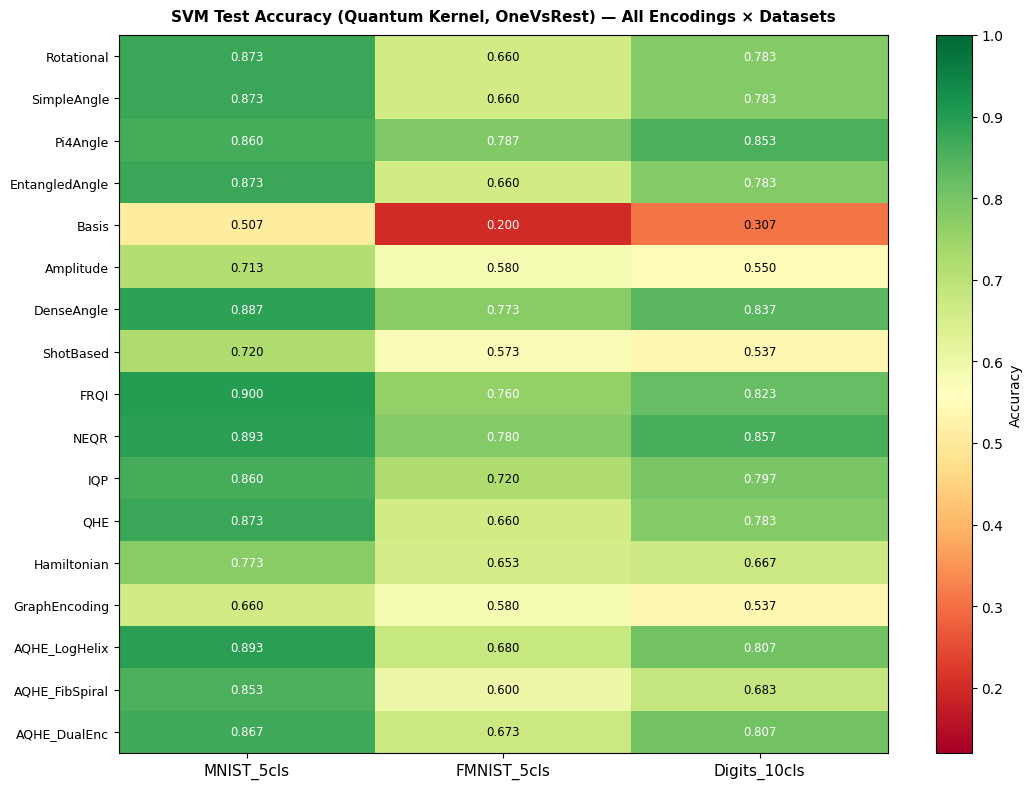

Saved: c:\Users\MANTAVYA\Downloads\qml_outputs_v10\summary_heatmap.png


In [17]:
enc_list = list(ENCODING_FNS.keys())
ds_list  = list(data.keys())

acc_matrix = np.full((len(enc_list), len(ds_list)), np.nan)
for j, ds in enumerate(ds_list):
    for i, enc in enumerate(enc_list):
        acc_matrix[i, j] = results.get(ds, {}).get(enc, {}).get("svm_acc", np.nan)

fig, ax = plt.subplots(figsize=(11, 8))
# Use dynamic vmin based on chance level (1/n_classes)
vmin_chance = min(1.0/N_CLASSES, 0.12)
im = ax.imshow(acc_matrix, cmap="RdYlGn", vmin=vmin_chance, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(ds_list)));  ax.set_xticklabels(ds_list,  fontsize=11)
ax.set_yticks(range(len(enc_list))); ax.set_yticklabels(enc_list, fontsize=9)
ax.set_title("SVM Test Accuracy (Quantum Kernel, OneVsRest) — All Encodings × Datasets",
             fontsize=11, fontweight="bold", pad=10)
for i in range(len(enc_list)):
    for j in range(len(ds_list)):
        val = acc_matrix[i, j]
        txt = f"{val:.3f}" if not np.isnan(val) else "-"
        color = "black" if (not np.isnan(val) and 0.3 < val < 0.75) else "white"
        ax.text(j, i, txt, ha="center", va="center", fontsize=8.5, color=color)
plt.colorbar(im, ax=ax, label="Accuracy")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "summary_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", OUTPUT_DIR / "summary_heatmap.png")


## 11 · Full VQC Training Run (real epoch curves)

Training VQC (2 layers) with FRQI on MNIST_5cls (5 classes) for 100 epochs ...
  Split: 360 train | 90 val | 150 test (unseen)
  Steps/epoch: 12  (batch=32)
  Epoch   5/100  loss=1.5289  tr_acc=0.403  val_acc=0.433
  Epoch  10/100  loss=1.4105  tr_acc=0.456  val_acc=0.467
  Epoch  15/100  loss=1.3820  tr_acc=0.514  val_acc=0.500
  Epoch  20/100  loss=1.3529  tr_acc=0.519  val_acc=0.511
  Epoch  25/100  loss=1.3363  tr_acc=0.525  val_acc=0.533
  Epoch  30/100  loss=1.3206  tr_acc=0.581  val_acc=0.567
  Epoch  35/100  loss=1.3225  tr_acc=0.575  val_acc=0.533
  Epoch  40/100  loss=1.3115  tr_acc=0.628  val_acc=0.556
  Epoch  45/100  loss=1.3069  tr_acc=0.631  val_acc=0.600
  Epoch  50/100  loss=1.3058  tr_acc=0.606  val_acc=0.589
  Epoch  55/100  loss=1.2947  tr_acc=0.633  val_acc=0.622
  Epoch  60/100  loss=1.2910  tr_acc=0.636  val_acc=0.622
  Epoch  65/100  loss=1.2927  tr_acc=0.653  val_acc=0.644
  Epoch  70/100  loss=1.2973  tr_acc=0.667  val_acc=0.644
  Epoch  75/100  loss=1.2910  t

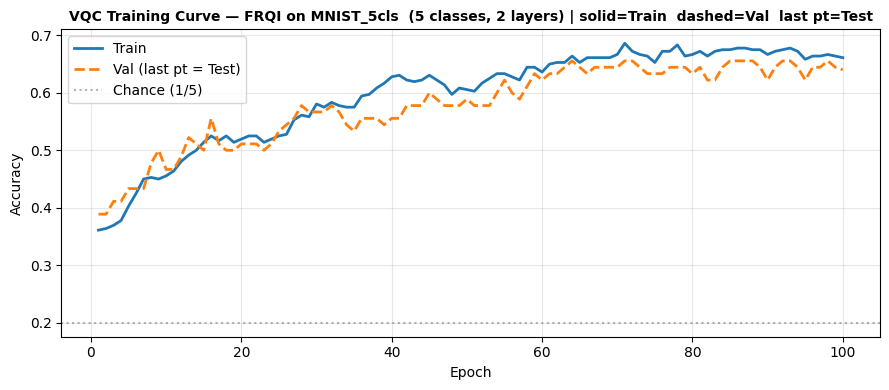

Final test accuracy: 0.6400  (chance: 0.200)


In [35]:
DEMO_ENC = "FRQI"
DEMO_DS  = "MNIST_5cls"

Xtr_d, Xte_d, ytr_d, yte_d = data[DEMO_DS]
enc_fn_d = ENCODING_FNS[DEMO_ENC]
n_cls_d  = len(np.unique(np.concatenate([ytr_d, yte_d])))

print(f"Training VQC ({VQC_LAYERS} layers) with {DEMO_ENC} on {DEMO_DS} "
      f"({n_cls_d} classes) for 100 epochs ...")
_, tr_hist, te_hist = train_vqc_multiclass(enc_fn_d, Xtr_d, ytr_d, Xte_d, yte_d, batch_size=BATCH_SIZE,n_epochs=100)

epochs = np.arange(1, len(te_hist) + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, tr_hist, label="Train", linewidth=2)
ax.plot(epochs, te_hist, label="Val (last pt = Test)",  linewidth=2, linestyle="--")
ax.axhline(1.0 / n_cls_d, color="gray", linestyle=":", alpha=0.6, label=f"Chance (1/{n_cls_d})")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title(f"VQC Training Curve — {DEMO_ENC} on {DEMO_DS}  "
             f"({n_cls_d} classes, {VQC_LAYERS} layers) | solid=Train  dashed=Val  last pt=Test",
             fontsize=10, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"vqc_curve_{DEMO_ENC}_{DEMO_DS}.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Final test accuracy: {te_hist[-1]:.4f}  (chance: {1/n_cls_d:.3f})")


## 12 · Comparative Bar Chart — All Encodings per Dataset

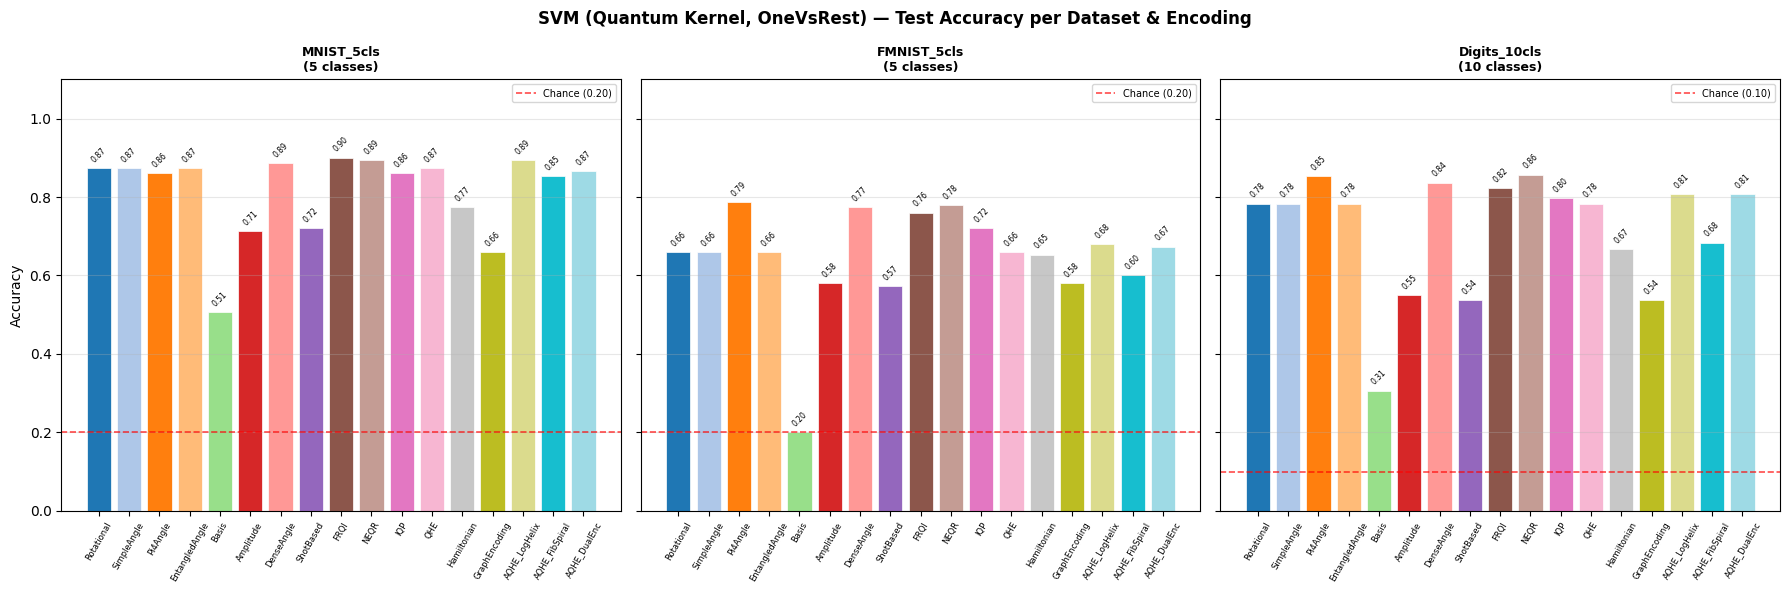

Saved: c:\Users\MANTAVYA\Downloads\qml_outputs_v10\bar_chart_all.png


In [36]:
ds_list  = list(data.keys())
enc_list = list(ENCODING_FNS.keys())

fig, axes = plt.subplots(1, len(ds_list), figsize=(18, 6), sharey=True)
palette = plt.cm.tab20(np.linspace(0, 1, len(enc_list)))

for ax, ds in zip(axes, ds_list):
    n_cls = len(np.unique(np.concatenate([data[ds][2], data[ds][3]])))
    chance = 1.0 / n_cls
    accs = [results.get(ds, {}).get(enc, {}).get("svm_acc", np.nan) for enc in enc_list]
    bars = ax.bar(enc_list, accs, color=palette, edgecolor="white", linewidth=0.5)
    ax.axhline(chance, color="red", linestyle="--", linewidth=1.2, alpha=0.7,
               label=f"Chance ({chance:.2f})")
    for bar, acc in zip(bars, accs):
        if not np.isnan(acc):
            ax.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f"{acc:.2f}",
                    ha="center", va="bottom", fontsize=5.5, rotation=45)
    ax.set_title(f"{ds}\n({n_cls} classes)", fontsize=9, fontweight="bold")
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Accuracy" if ds == ds_list[0] else "")
    ax.tick_params(axis="x", rotation=60, labelsize=6)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle("SVM (Quantum Kernel, OneVsRest) — Test Accuracy per Dataset & Encoding",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bar_chart_all.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved:", OUTPUT_DIR / "bar_chart_all.png")


## 13 · Encoding Group Comparison (Radar / Spider Chart)

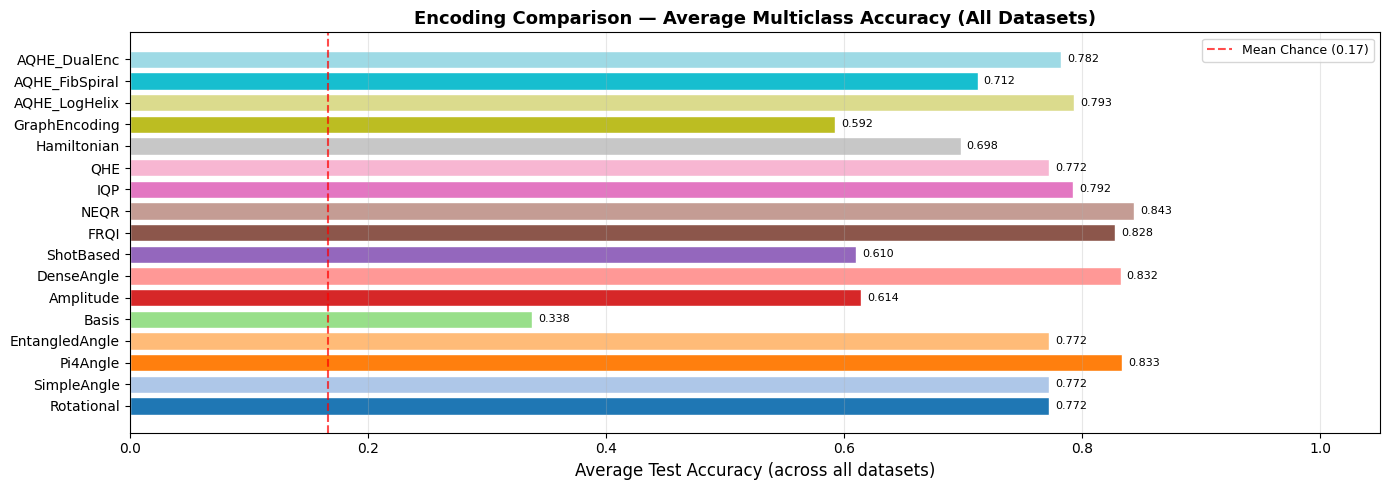


FINAL RANKING — Encodings by Average Multiclass Accuracy
      Encoding  Avg_Accuracy  MNIST_5cls  FMNIST_5cls  Digits_10cls
          NEQR        0.8433      0.8933       0.7800        0.8567
      Pi4Angle        0.8333      0.8600       0.7867        0.8533
    DenseAngle        0.8322      0.8867       0.7733        0.8367
          FRQI        0.8278      0.9000       0.7600        0.8233
 AQHE_LogHelix        0.7933      0.8933       0.6800        0.8067
           IQP        0.7922      0.8600       0.7200        0.7967
  AQHE_DualEnc        0.7822      0.8667       0.6733        0.8067
    Rotational        0.7722      0.8733       0.6600        0.7833
   SimpleAngle        0.7722      0.8733       0.6600        0.7833
           QHE        0.7722      0.8733       0.6600        0.7833
EntangledAngle        0.7722      0.8733       0.6600        0.7833
AQHE_FibSpiral        0.7122      0.8533       0.6000        0.6833
   Hamiltonian        0.6978      0.7733       0.6533     

In [24]:
# Radar chart comparing average accuracy across datasets per encoding
enc_list = list(ENCODING_FNS.keys())
ds_list  = list(data.keys())

avg_accs = []
for enc in enc_list:
    vals = [results.get(ds, {}).get(enc, {}).get("svm_acc", np.nan) for ds in ds_list]
    valid = [v for v in vals if not np.isnan(v)]
    avg_accs.append(np.mean(valid) if valid else np.nan)

# Bar chart of average accuracy (simpler and more readable than radar for 17 encodings)
fig, ax = plt.subplots(figsize=(14, 5))
colors_bar = plt.cm.tab20(np.linspace(0, 1, len(enc_list)))
bars = ax.barh(enc_list, avg_accs, color=colors_bar, edgecolor="white")
chance_avg = np.mean([1.0 / len(np.unique(np.concatenate([data[ds][2], data[ds][3]])))
                      for ds in ds_list])
ax.axvline(chance_avg, color="red", linestyle="--", linewidth=1.5, alpha=0.7,
           label=f"Mean Chance ({chance_avg:.2f})")
for bar, val in zip(bars, avg_accs):
    if not np.isnan(val):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8)
ax.set_xlabel("Average Test Accuracy (across all datasets)", fontsize=12)
ax.set_title("Encoding Comparison — Average Multiclass Accuracy (All Datasets)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="x", alpha=0.3)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "encoding_avg_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary DataFrame
df_summary = pd.DataFrame({
    "Encoding": enc_list,
    "Avg_Accuracy": avg_accs,
    **{ds: [results.get(ds, {}).get(enc, {}).get("svm_acc", np.nan) for enc in enc_list]
       for ds in ds_list}
})
df_summary = df_summary.sort_values("Avg_Accuracy", ascending=False).reset_index(drop=True)
print("\n" + "="*70)
print("FINAL RANKING — Encodings by Average Multiclass Accuracy")
print("="*70)
print(df_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
df_summary.to_csv(OUTPUT_DIR / "encoding_ranking.csv", index=False)
print(f"\nSaved CSV: {OUTPUT_DIR / 'encoding_ranking.csv'}")


## 14 · Observations & Next Steps

### Interpretation guide
- **Chance level**: 1/K where K = number of classes (0.20 for 5-class, 0.10 for 10-class).
  Any encoding significantly above chance is capturing real structure.
- **VQC layers = 6**: Deeper VQC (vs v9's 2) has more expressivity but is susceptible
  to barren plateaus. Monitor whether train/test accuracy diverge — if so, reduce layers.
- **IQP (corrected)**: All-pairs RZZ in 2 layers creates an exponentially rich kernel.
  Expected to generalize well to multiclass but slowest encoding at O(n²) gate depth.
- **QHE (corrected)**: IQFT-based interference pattern is naturally suited to frequency-rich
  datasets; expect strong performance on MNIST (frequency structure in PCA components).
- **AQHE variants**: LogHelix > FibSpiral > DualEnc for datasets with concentrated low-value
  PCA mass (typical after PCA of natural images). All three are non-stationary.
- **Hamiltonian**: Richest kernel (XX + Z interactions), best suited for datasets with strong
  pairwise feature correlations. Deepest circuit; verify ETA before full run.

### Recommended workflow
1. Run with `QUICK_TEST = True` (default) — confirms everything works in ~5 min.
2. Set `QUICK_TEST = False`, restart kernel, run all cells (watch ETA in §6 + §8).
3. If ETA is too long, reduce `N_SAMPLES` (e.g., 200/class) — runtime scales ~quadratically.
4. Set `RUN_VQC = True` in §6 only after full SVM kernel run is complete (much slower).
5. Install `tensorflow` (§0a) if datasets show `PROXY` status — needed for real MNIST/FMNIST
   at the full 500/class scale (sklearn digits caps at ~180/class).

### Still open
1. **Noise robustness** — run with depolarizing noise model to compare encoding resilience.
2. **CKA metric** — add `centered_kernel_alignment()` to compare kernel geometry across encodings.
3. **AQHE-v6full** — combines FibSpiral + LogPhase + HoPE + mixed CPS gates; most expressive QHE variant.
4. **Data re-uploading VQC** — encoding applied at every layer (Pérez-Salinas et al.) for deeper feature extraction.
